# Stage 2: Compress-Decompress Error Propagation

Test how repeated QTT compression/decompression cycles affect LBM simulation accuracy.

**Key question:** Does truncation error accumulate, and if so, how fast?

**Experimental variables:**
- Compression frequency N (every N steps): 1, 10, 100, 1000, ∞ (baseline)
- Bond dimension χ: exact required, 1.5×, 2× (from Stage 1)
- Mappings: snake, hilbert
- Reynolds: 100, 1000, 5000

**Metrics:**
- `u_err(t)` - velocity error vs reference
- `mass_drift(t)` - total mass deviation
- `momentum_drift(t)` - momentum deviation

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from lbm import D2Q9, compute_equilibrium, stream, collide_bgk, apply_bounce_back, apply_bounce_back_moving_top
from lbm.collision import compute_moments
from simulations.lid_driven_cavity import create_cavity_walls
from tn.compression import compress_populations, decompress_populations

# Velocity names for reference
velocity_names = ['Rest', 'East', 'North', 'West', 'South', 'NE', 'NW', 'SW', 'SE']

## 1. Setup & Reference Values from Stage 1

Required χ for u_err < 1% (from Stage 1 cavity experiments):

In [57]:
# Stage 1 results: minimum χ for u_err < 1%
CHI_REQUIRED = {
    # (Re, mapping): chi
    (100, 'snake'): 10,
    (100, 'hilbert'): 16,
    (1000, 'snake'): 12,
    (1000, 'hilbert'): 24,
    (5000, 'snake'): 32,
    (5000, 'hilbert'): 48,
}

# Experimental parameters
N_VALUES = [1, 10, 100, 1000]  # compression every N steps
CHI_MULTIPLIERS = [1.0, 1.5, 2.0]  # multipliers for required chi
RE_VALUES = [100, 1000, 5000]
MAPPINGS = ['snake']

# Grid size
GRID_SIZE = 256

# Simulation lengths (from Stage 1)
NT_VALUES = {
    100: 30000,
    1000: 80000,
    5000: 150000,
}

print("Required χ from Stage 1:")
print(f"{'Re':>6} {'snake':>8} {'hilbert':>10}")
print("-" * 28)
for Re in RE_VALUES:
    print(f"{Re:>6} {CHI_REQUIRED[(Re, 'snake')]:>8} {CHI_REQUIRED[(Re, 'hilbert')]:>10}")

Required χ from Stage 1:
    Re    snake    hilbert
----------------------------
   100       10         16
  1000       12         24
  5000       32         48


## 2. Core Simulation Function with Compression

In [95]:
def run_cavity_with_compression(n, Re, u_lid=0.1, nt=None, 
                                 compress_every=None, max_bond=None, mapping='snake',
                                 snapshot_times=None, verbose=True,
                                 convergence_tol=1e-5, convergence_check_every=1):
    """
    Run cavity simulation with periodic compression/decompression.
    
    Args:
        n: Grid size
        Re: Reynolds number
        u_lid: Lid velocity
        nt: Total timesteps (default from NT_VALUES)
        compress_every: Compress every N steps (None = no compression)
        max_bond: Bond dimension for compression
        mapping: 'snake' or 'hilbert'
        snapshot_times: List of timesteps to save (default: 10 evenly spaced)
        verbose: Print progress
        convergence_tol: Stop when RELATIVE max velocity change < this value (None = no check)
        convergence_check_every: Check convergence every N steps (1 = every step, standard)
    
    Returns:
        snapshots: List of dicts with t, rho, u, mass, momentum
        params: Simulation parameters (includes 'converged' and 'convergence_time')
    """
    if nt is None:
        nt = NT_VALUES.get(Re, 50000)  # Default to 50000 if Re not in dict
    
    # Physics setup
    L = n
    nu = u_lid * L / Re
    tau = 3 * nu + 0.5
    
    if tau <= 0.5:
        raise ValueError(f"tau={tau:.4f} <= 0.5, unstable!")
    
    walls, lid = create_cavity_walls(n)
    u_wall = np.array([u_lid, 0.0])
    
    # Initial conditions
    rho = np.ones((n, n))
    u = np.zeros((2, n, n))
    f = compute_equilibrium(D2Q9, rho, u)
    
    # Initial conservation quantities
    mass_0 = np.sum(rho)
    momentum_0 = np.array([np.sum(rho * u[0]), np.sum(rho * u[1])])
    
    # Snapshot times
    if snapshot_times is None:
        snapshot_times = [int(nt * frac) for frac in [0.01, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0]]
    snapshot_times = sorted(set(snapshot_times))
    
    snapshots = []
    compression_count = 0
    
    # Convergence tracking
    u_prev = None  # Changed: start with None instead of zeros
    converged = False
    final_t = nt
    last_u_change = None
    
    if verbose:
        compress_str = f"every {compress_every} steps, χ={max_bond}" if compress_every else "none"
        conv_str = f"tol={convergence_tol}" if convergence_tol else "disabled"
        print(f"Re={Re}, τ={tau:.4f}, compression: {compress_str}, convergence: {conv_str}")
    
    for t in range(1, nt + 1):
        # LBM step
        f = collide_bgk(D2Q9, f, tau)
        f = stream(D2Q9, f)
        f = apply_bounce_back(D2Q9, f, walls)
        f = apply_bounce_back_moving_top(D2Q9, f, u_wall)
        
        # Compression cycle
        if compress_every is not None and t % compress_every == 0:
            mps_list, meta = compress_populations(f, max_bond=max_bond, mapping=mapping)
            f = decompress_populations(mps_list, meta)
            compression_count += 1
        
        # Convergence check
        if convergence_tol is not None and t % convergence_check_every == 0:
            rho_check, u_check = compute_moments(D2Q9, f)
            
            if u_prev is not None:
                # Use RELATIVE change (standard in LBM literature)
                u_max_curr = np.max(np.abs(u_check)) + 1e-10  # avoid div by zero
                u_change = np.max(np.abs(u_check - u_prev)) / u_max_curr
                last_u_change = u_change
                
                if u_change < convergence_tol:
                    if verbose:
                        print(f"  Converged at t={t} (Δu_rel={u_change:.2e} < {convergence_tol})")
                    converged = True
                    final_t = t
                    # Save final snapshot before breaking
                    mass_t = np.sum(rho_check)
                    momentum_t = np.array([np.sum(rho_check * u_check[0]), np.sum(rho_check * u_check[1])])
                    snapshots.append({
                        't': t, 'rho': rho_check.copy(), 'u': u_check.copy(),
                        'mass': mass_t, 'momentum': momentum_t.copy(),
                        'mass_drift': (mass_t - mass_0) / mass_0,
                        'momentum_drift': np.linalg.norm(momentum_t - momentum_0),
                        'compressions_so_far': compression_count,
                    })
                    break
            
            u_prev = u_check.copy()
        
        # Save snapshot
        if t in snapshot_times:
            rho_t, u_t = compute_moments(D2Q9, f)
            mass_t = np.sum(rho_t)
            momentum_t = np.array([np.sum(rho_t * u_t[0]), np.sum(rho_t * u_t[1])])
            
            snapshots.append({
                't': t,
                'rho': rho_t.copy(),
                'u': u_t.copy(),
                'mass': mass_t,
                'momentum': momentum_t.copy(),
                'mass_drift': (mass_t - mass_0) / mass_0,
                'momentum_drift': np.linalg.norm(momentum_t - momentum_0),
                'compressions_so_far': compression_count,
            })
            
            if verbose:
                u_max = np.max(np.sqrt(u_t[0]**2 + u_t[1]**2))
                # Show convergence progress
                delta_str = f", Δu_rel={last_u_change:.2e}" if last_u_change is not None else ""
                print(f"  t={t:>6}/{nt} ({t/nt*100:>5.1f}%), u_max={u_max:.4f}{delta_str}, compressions={compression_count}")
        
        # Stability check
        if t % 1000 == 0 and np.any(np.isnan(f)):
            print(f"  NaN detected at t={t}!")
            final_t = t
            break
    
    params = {
        'n': n, 'Re': Re, 'tau': tau, 'nt': nt,
        'compress_every': compress_every, 'max_bond': max_bond, 'mapping': mapping,
        'total_compressions': compression_count,
        'mass_0': mass_0, 'momentum_0': momentum_0,
        'converged': converged,
        'convergence_time': final_t,
    }
    
    return snapshots, params

In [91]:
def compute_velocity_error(u_test, u_ref):
    """Compute relative L2 error in velocity field."""
    return np.linalg.norm(u_test - u_ref) / np.linalg.norm(u_ref)


def compare_to_reference(snapshots_test, snapshots_ref):
    """
    Compare test snapshots to reference (no compression).
    
    Returns list of dicts with error metrics at each snapshot time.
    """
    # Build lookup for reference
    ref_by_t = {s['t']: s for s in snapshots_ref}
    
    results = []
    for s_test in snapshots_test:
        t = s_test['t']
        if t not in ref_by_t:
            continue
        s_ref = ref_by_t[t]
        
        u_err = compute_velocity_error(s_test['u'], s_ref['u'])
        
        results.append({
            't': t,
            'u_err': u_err,
            'mass_drift': s_test['mass_drift'],
            'momentum_drift': s_test['momentum_drift'],
            'compressions': s_test['compressions_so_far'],
        })
    
    return results

## 3. Baseline Runs (No Compression)

Run vanilla LBM for each Re to use as reference.

In [13]:
# Run baseline simulations (no compression)
baselines = {}

for Re in RE_VALUES:
    print(f"\n=== Baseline Re={Re} ===")
    snapshots, params = run_cavity_with_compression(
        n=GRID_SIZE, Re=Re, compress_every=None, verbose=True
    )
    baselines[Re] = {'snapshots': snapshots, 'params': params}

print("\nBaseline simulations complete!")


=== Baseline Re=100 ===
Re=100, τ=1.2680, compression: none
  t=   300/30000 (  1.0%), u_max=0.1013, compressions=0
  t=  1500/30000 (  5.0%), u_max=0.1004, compressions=0
  t=  3000/30000 ( 10.0%), u_max=0.1003, compressions=0
  t=  6000/30000 ( 20.0%), u_max=0.1001, compressions=0
  t= 12000/30000 ( 40.0%), u_max=0.1001, compressions=0
  t= 18000/30000 ( 60.0%), u_max=0.1002, compressions=0
  t= 24000/30000 ( 80.0%), u_max=0.1001, compressions=0
  t= 30000/30000 (100.0%), u_max=0.1001, compressions=0

=== Baseline Re=1000 ===
Re=1000, τ=0.5768, compression: none
  t=   800/80000 (  1.0%), u_max=0.1078, compressions=0
  t=  4000/80000 (  5.0%), u_max=0.1069, compressions=0
  t=  8000/80000 ( 10.0%), u_max=0.1072, compressions=0
  t= 16000/80000 ( 20.0%), u_max=0.1070, compressions=0
  t= 32000/80000 ( 40.0%), u_max=0.1070, compressions=0
  t= 48000/80000 ( 60.0%), u_max=0.1069, compressions=0
  t= 64000/80000 ( 80.0%), u_max=0.1069, compressions=0
  t= 80000/80000 (100.0%), u_max=0.1

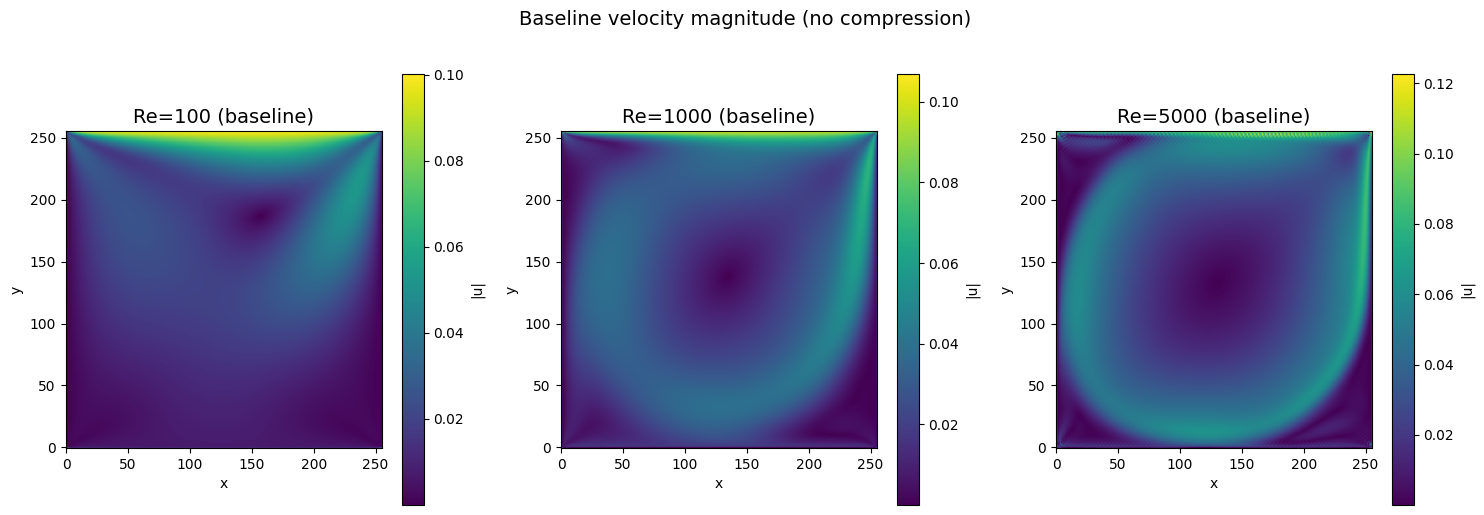

In [14]:
# Visualize baseline final states
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, Re in zip(axes, RE_VALUES):
    u_final = baselines[Re]['snapshots'][-1]['u']
    speed = np.sqrt(u_final[0]**2 + u_final[1]**2)
    im = ax.imshow(speed.T, cmap='viridis', origin='lower')
    ax.set_title(f'Re={Re} (baseline)', fontsize=14)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    plt.colorbar(im, ax=ax, label='|u|')

plt.suptitle('Baseline velocity magnitude (no compression)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Compression Frequency Experiments

### 5.1 Re=100

In [ ]:
# Re=100 experiments
Re = 100
results_100 = {}

for mapping in MAPPINGS:
    chi_base = CHI_REQUIRED[(Re, mapping)]
    
    for chi_mult in CHI_MULTIPLIERS:
        chi = int(chi_base * chi_mult)
        
        for N in N_VALUES:
            print(f"\nRe={Re}, {mapping}, χ={chi} ({chi_mult}x), N={N}")
            
            snapshots, params = run_cavity_with_compression(
                n=GRID_SIZE, Re=Re,
                compress_every=N, max_bond=chi, mapping=mapping,
                verbose=True
            )
            
            # Compare to baseline
            errors = compare_to_reference(snapshots, baselines[Re]['snapshots'])
            
            results_100[(mapping, chi_mult, N)] = {
                'snapshots': snapshots,
                'params': params,
                'errors': errors,
                'chi': chi,
            }
            
            # Print final error
            final_err = errors[-1]['u_err']
            print(f"  Final u_err: {final_err:.2e}")


Re=100, snake, χ=10 (1.0x), N=1
Re=100, τ=1.2680, compression: every 1 steps, χ=10
  t=   300/30000 (  1.0%), u_max=0.1015, compressions=300
  t=  1500/30000 (  5.0%), u_max=0.1004, compressions=1500
  t=  3000/30000 ( 10.0%), u_max=0.1005, compressions=3000
  t=  6000/30000 ( 20.0%), u_max=0.1002, compressions=6000


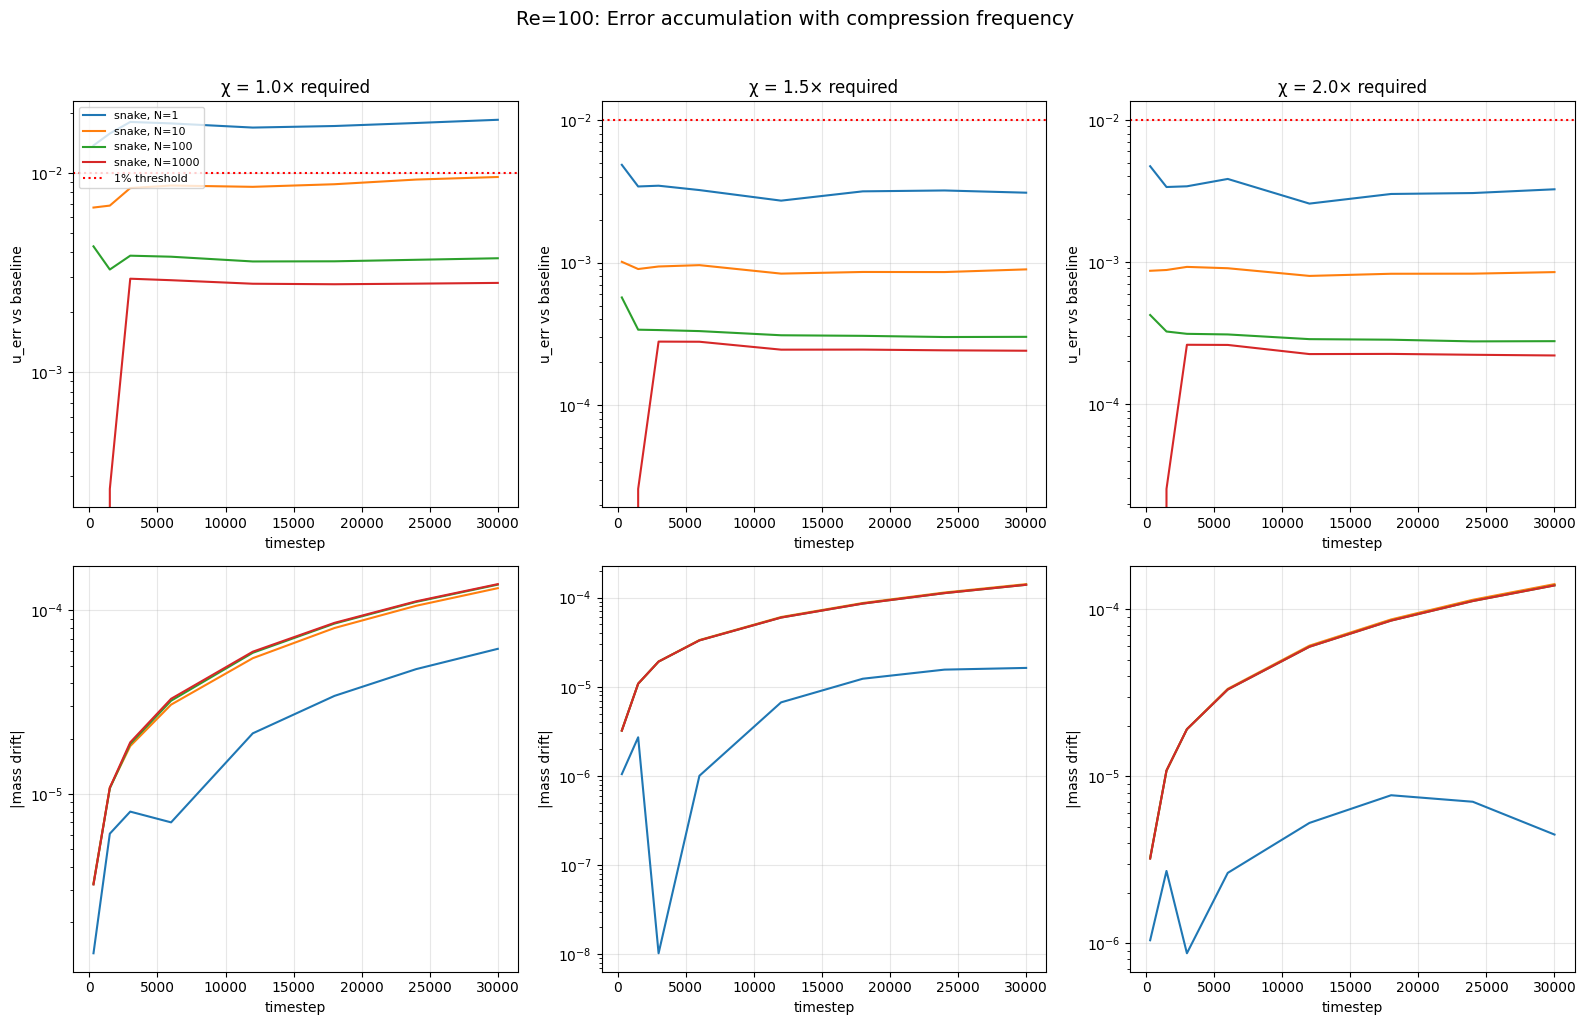

In [ ]:
# Plot Re=100 results
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

colors_N = {1: 'C0', 10: 'C1', 100: 'C2', 1000: 'C3'}
linestyles_mapping = {'snake': '-', 'hilbert': '--'}

for col, chi_mult in enumerate(CHI_MULTIPLIERS):
    # Top row: velocity error over time
    ax = axes[0, col]
    for mapping in MAPPINGS:
        for N in N_VALUES:
            key = (mapping, chi_mult, N)
            if key not in results_100:
                continue
            errors = results_100[key]['errors']
            ts = [e['t'] for e in errors]
            u_errs = [e['u_err'] for e in errors]
            label = f"{mapping}, N={N}"
            ax.semilogy(ts, u_errs, linestyle=linestyles_mapping[mapping],
                       color=colors_N[N], label=label, linewidth=1.5)
    
    chi = int(CHI_REQUIRED[(100, 'snake')] * chi_mult)
    ax.set_title(f'χ = {chi_mult}× required', fontsize=12)
    ax.set_xlabel('timestep')
    ax.set_ylabel('u_err vs baseline')
    ax.axhline(0.01, color='red', linestyle=':', label='1% threshold')
    ax.grid(True, alpha=0.3)
    if col == 0:
        ax.legend(fontsize=8, loc='upper left')
    
    # Bottom row: mass drift
    ax = axes[1, col]
    for mapping in MAPPINGS:
        for N in N_VALUES:
            key = (mapping, chi_mult, N)
            if key not in results_100:
                continue
            errors = results_100[key]['errors']
            ts = [e['t'] for e in errors]
            mass_drifts = [abs(e['mass_drift']) for e in errors]
            ax.semilogy(ts, mass_drifts, linestyle=linestyles_mapping[mapping],
                       color=colors_N[N], linewidth=1.5)
    
    ax.set_xlabel('timestep')
    ax.set_ylabel('|mass drift|')
    ax.grid(True, alpha=0.3)

plt.suptitle('Re=100: Error accumulation with compression frequency', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 5.2 Re=1000

In [18]:
# Re=1000 experiments
Re = 1000
results_1000 = {}

for mapping in MAPPINGS:
    chi_base = CHI_REQUIRED[(Re, mapping)]
    
    for chi_mult in CHI_MULTIPLIERS:
        chi = int(chi_base * chi_mult)
        
        for N in N_VALUES:
            print(f"\nRe={Re}, {mapping}, χ={chi} ({chi_mult}x), N={N}")
            
            snapshots, params = run_cavity_with_compression(
                n=GRID_SIZE, Re=Re,
                compress_every=N, max_bond=chi, mapping=mapping,
                verbose=True
            )
            
            errors = compare_to_reference(snapshots, baselines[Re]['snapshots'])
            
            results_1000[(mapping, chi_mult, N)] = {
                'snapshots': snapshots,
                'params': params,
                'errors': errors,
                'chi': chi,
            }
            
            final_err = errors[-1]['u_err']
            print(f"  Final u_err: {final_err:.2e}")


Re=1000, snake, χ=12 (1.0x), N=1
Re=1000, τ=0.5768, compression: every 1 steps, χ=12
  t=   800/80000 (  1.0%), u_max=0.1079, compressions=800
  t=  4000/80000 (  5.0%), u_max=0.1072, compressions=4000
  t=  8000/80000 ( 10.0%), u_max=0.1071, compressions=8000
  t= 16000/80000 ( 20.0%), u_max=0.1072, compressions=16000
  t= 32000/80000 ( 40.0%), u_max=0.1070, compressions=32000
  t= 48000/80000 ( 60.0%), u_max=0.1068, compressions=48000
  t= 64000/80000 ( 80.0%), u_max=0.1068, compressions=64000
  t= 80000/80000 (100.0%), u_max=0.1067, compressions=80000
  Final u_err: 9.65e-02

Re=1000, snake, χ=12 (1.0x), N=10
Re=1000, τ=0.5768, compression: every 10 steps, χ=12
  t=   800/80000 (  1.0%), u_max=0.1078, compressions=80
  t=  4000/80000 (  5.0%), u_max=0.1071, compressions=400
  t=  8000/80000 ( 10.0%), u_max=0.1076, compressions=800
  t= 16000/80000 ( 20.0%), u_max=0.1077, compressions=1600
  t= 32000/80000 ( 40.0%), u_max=0.1071, compressions=3200
  t= 48000/80000 ( 60.0%), u_max=0.

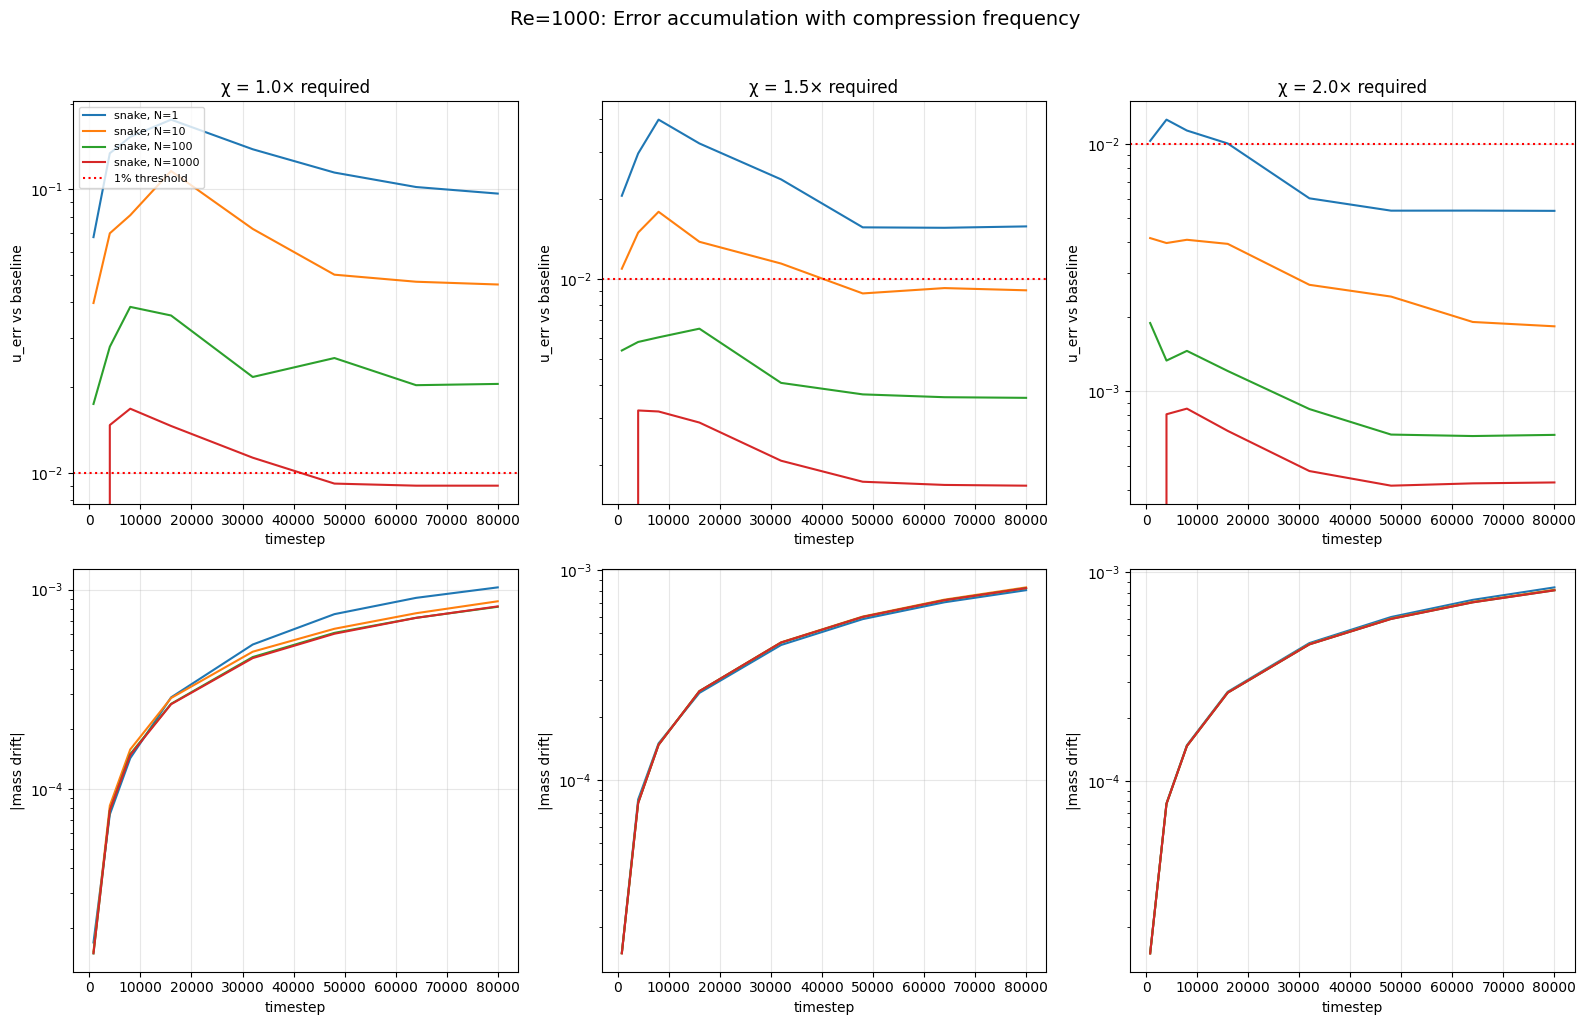

In [19]:
# Plot Re=1000 results (same structure as Re=100)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for col, chi_mult in enumerate(CHI_MULTIPLIERS):
    ax = axes[0, col]
    for mapping in MAPPINGS:
        for N in N_VALUES:
            key = (mapping, chi_mult, N)
            if key not in results_1000:
                continue
            errors = results_1000[key]['errors']
            ts = [e['t'] for e in errors]
            u_errs = [e['u_err'] for e in errors]
            label = f"{mapping}, N={N}"
            ax.semilogy(ts, u_errs, linestyle=linestyles_mapping[mapping],
                       color=colors_N[N], label=label, linewidth=1.5)
    
    ax.set_title(f'χ = {chi_mult}× required', fontsize=12)
    ax.set_xlabel('timestep')
    ax.set_ylabel('u_err vs baseline')
    ax.axhline(0.01, color='red', linestyle=':', label='1% threshold')
    ax.grid(True, alpha=0.3)
    if col == 0:
        ax.legend(fontsize=8, loc='upper left')
    
    ax = axes[1, col]
    for mapping in MAPPINGS:
        for N in N_VALUES:
            key = (mapping, chi_mult, N)
            if key not in results_1000:
                continue
            errors = results_1000[key]['errors']
            ts = [e['t'] for e in errors]
            mass_drifts = [abs(e['mass_drift']) for e in errors]
            ax.semilogy(ts, mass_drifts, linestyle=linestyles_mapping[mapping],
                       color=colors_N[N], linewidth=1.5)
    
    ax.set_xlabel('timestep')
    ax.set_ylabel('|mass drift|')
    ax.grid(True, alpha=0.3)

plt.suptitle('Re=1000: Error accumulation with compression frequency', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 5.3 Re=5000

In [29]:
# Re=5000 experiments
# NOTE: χ=1.0× (32) is unstable and causes divergence at N>=100
# We document the partial 1.0× results and run 1.5× and 2.0× only

Re = 5000
results_5000 = {}

# Add documented 1.0× results (from previous run before crash)
# N=1 and N=10 completed with high error, N=100 diverged
results_5000[('snake', 1.0, 1)] = {
    'errors': [{'t': 150000, 'u_err': 0.191, 'compressions': 150000, 
                'mass_drift': float('nan'), 'momentum_drift': float('nan')}],
    'chi': 32,
    'status': 'completed_high_error'
}
results_5000[('snake', 1.0, 10)] = {
    'errors': [{'t': 150000, 'u_err': 0.198, 'compressions': 15000,
                'mass_drift': float('nan'), 'momentum_drift': float('nan')}],
    'chi': 32,
    'status': 'completed_high_error'
}
results_5000[('snake', 1.0, 100)] = {
    'errors': [{'t': 30000, 'u_err': float('inf'), 'compressions': 300,
                'mass_drift': float('nan'), 'momentum_drift': float('nan')}],
    'chi': 32,
    'status': 'DIVERGED'
}
results_5000[('snake', 1.0, 1000)] = {
    'errors': [{'t': 0, 'u_err': float('inf'), 'compressions': 0,
                'mass_drift': float('nan'), 'momentum_drift': float('nan')}],
    'chi': 32,
    'status': 'SKIPPED'
}

print("Re=5000: χ=1.0× results (documented from previous run):")
print("  N=1:    u_err=19.1% (high but stable)")
print("  N=10:   u_err=19.8% (high but stable)")
print("  N=100:  DIVERGED (NaN/Inf at t≈30000)")
print("  N=1000: SKIPPED")
print("\nRunning 1.5× and 2.0× experiments...\n")

# Only run 1.5× and 2.0× multipliers
for mapping in MAPPINGS:
    chi_base = CHI_REQUIRED[(Re, mapping)]
    
    for chi_mult in [1.5, 2.0]:  # Skip 1.0× which is unstable
        chi = int(chi_base * chi_mult)
        
        for N in N_VALUES:
            print(f"\nRe={Re}, {mapping}, χ={chi} ({chi_mult}x), N={N}")
            
            snapshots, params = run_cavity_with_compression(
                n=GRID_SIZE, Re=Re,
                compress_every=N, max_bond=chi, mapping=mapping,
                verbose=True
            )
            
            errors = compare_to_reference(snapshots, baselines[Re]['snapshots'])
            
            results_5000[(mapping, chi_mult, N)] = {
                'snapshots': snapshots,
                'params': params,
                'errors': errors,
                'chi': chi,
            }
            
            final_err = errors[-1]['u_err']
            print(f"  Final u_err: {final_err:.2e}")

Re=5000: χ=1.0× results (documented from previous run):
  N=1:    u_err=19.1% (high but stable)
  N=10:   u_err=19.8% (high but stable)
  N=100:  DIVERGED (NaN/Inf at t≈30000)
  N=1000: SKIPPED

Running 1.5× and 2.0× experiments...


Re=5000, snake, χ=48 (1.5x), N=1
Re=5000, τ=0.5154, compression: every 1 steps, χ=48
  t=  1500/150000 (  1.0%), u_max=0.1265, compressions=1500
  t=  7500/150000 (  5.0%), u_max=0.1263, compressions=7500
  t= 15000/150000 ( 10.0%), u_max=0.1260, compressions=15000
  t= 30000/150000 ( 20.0%), u_max=0.1256, compressions=30000
  t= 60000/150000 ( 40.0%), u_max=0.1249, compressions=60000
  t= 90000/150000 ( 60.0%), u_max=0.1242, compressions=90000
  t=120000/150000 ( 80.0%), u_max=0.1238, compressions=120000
  t=150000/150000 (100.0%), u_max=0.1233, compressions=150000
  Final u_err: 1.77e-01

Re=5000, snake, χ=48 (1.5x), N=10
Re=5000, τ=0.5154, compression: every 10 steps, χ=48
  t=  1500/150000 (  1.0%), u_max=0.1265, compressions=150
  t=  7500/150000 (  5

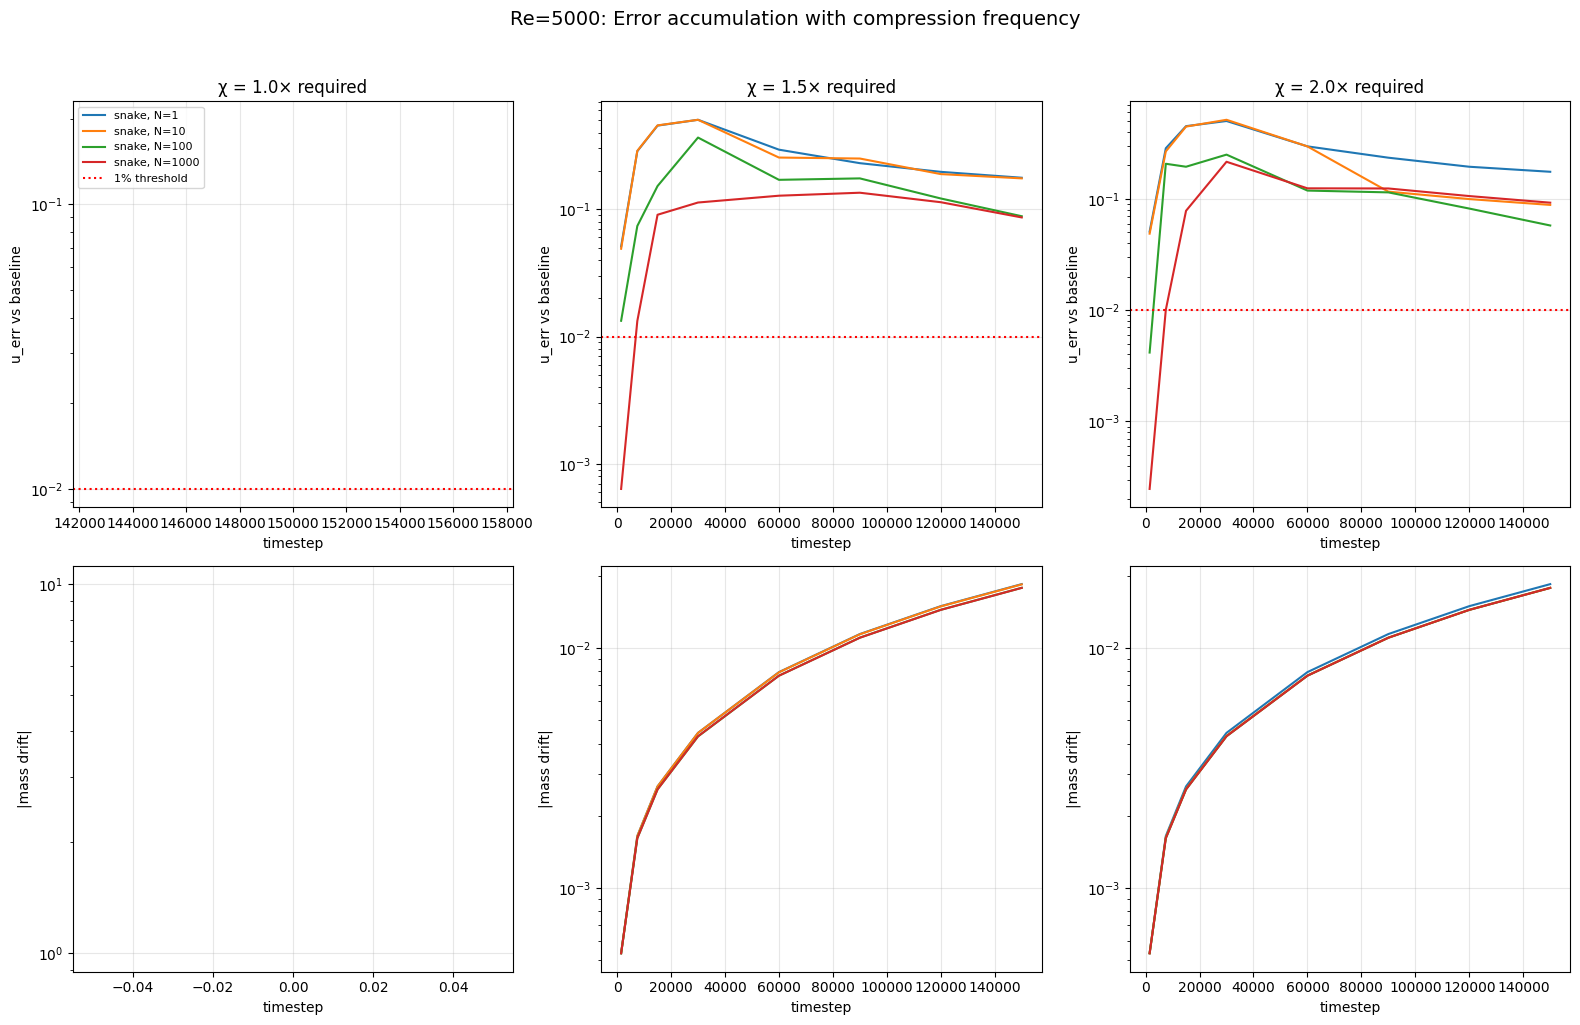

In [36]:
# Plot Re=5000 results
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for col, chi_mult in enumerate(CHI_MULTIPLIERS):
    ax = axes[0, col]
    for mapping in MAPPINGS:
        for N in N_VALUES:
            key = (mapping, chi_mult, N)
            if key not in results_5000:
                continue
            errors = results_5000[key]['errors']
            ts = [e['t'] for e in errors]
            u_errs = [e['u_err'] for e in errors]
            label = f"{mapping}, N={N}"
            ax.semilogy(ts, u_errs, linestyle=linestyles_mapping[mapping],
                       color=colors_N[N], label=label, linewidth=1.5)
    
    ax.set_title(f'χ = {chi_mult}× required', fontsize=12)
    ax.set_xlabel('timestep')
    ax.set_ylabel('u_err vs baseline')
    ax.axhline(0.01, color='red', linestyle=':', label='1% threshold')
    ax.grid(True, alpha=0.3)
    if col == 0:
        ax.legend(fontsize=8, loc='upper left')
    
    ax = axes[1, col]
    for mapping in MAPPINGS:
        for N in N_VALUES:
            key = (mapping, chi_mult, N)
            if key not in results_5000:
                continue
            errors = results_5000[key]['errors']
            ts = [e['t'] for e in errors]
            mass_drifts = [abs(e['mass_drift']) for e in errors]
            ax.semilogy(ts, mass_drifts, linestyle=linestyles_mapping[mapping],
                       color=colors_N[N], linewidth=1.5)
    
    ax.set_xlabel('timestep')
    ax.set_ylabel('|mass drift|')
    ax.grid(True, alpha=0.3)

plt.suptitle('Re=5000: Error accumulation with compression frequency', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Error Accumulation Analysis

Analyze how error scales with number of compression cycles.

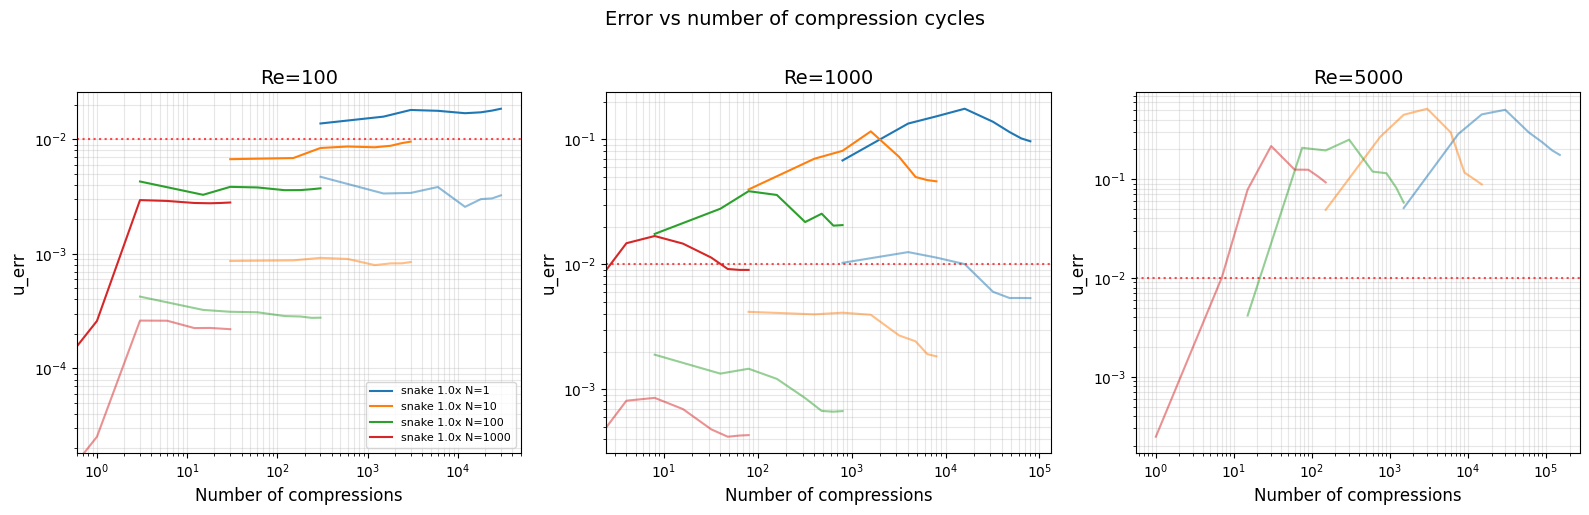

In [37]:
# Combine all results
all_results = {
    100: results_100,
    1000: results_1000,
    5000: results_5000,
}

# Error vs number of compressions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, Re in zip(axes, RE_VALUES):
    results = all_results[Re]
    
    for mapping in MAPPINGS:
        for chi_mult in [1.0, 2.0]:  # Show 1x and 2x
            for N in N_VALUES:
                key = (mapping, chi_mult, N)
                if key not in results:
                    continue
                
                errors = results[key]['errors']
                n_compressions = [e['compressions'] for e in errors]
                u_errs = [e['u_err'] for e in errors]
                
                style = '-' if mapping == 'snake' else '--'
                alpha = 1.0 if chi_mult == 1.0 else 0.5
                label = f"{mapping} {chi_mult}x N={N}" if chi_mult == 1.0 else None
                
                ax.loglog(n_compressions, u_errs, style,
                         color=colors_N[N], alpha=alpha, linewidth=1.5, label=label)
    
    ax.set_xlabel('Number of compressions', fontsize=12)
    ax.set_ylabel('u_err', fontsize=12)
    ax.set_title(f'Re={Re}', fontsize=14)
    ax.axhline(0.01, color='red', linestyle=':', alpha=0.7)
    ax.grid(True, alpha=0.3, which='both')
    if Re == 100:
        ax.legend(fontsize=8)

plt.suptitle('Error vs number of compression cycles', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [39]:
# Error per compression cycle
print("Error per compression cycle (final_err / n_compressions):")
print(f"{'Re':>6} {'mapping':>8} {'χ_mult':>8} {'N':>6} {'n_comp':>8} {'final_err':>12} {'err/comp':>12}")
print("-" * 75)

for Re in RE_VALUES:
    results = all_results[Re]
    for mapping in MAPPINGS:
        for chi_mult in CHI_MULTIPLIERS:
            for N in N_VALUES:
                key = (mapping, chi_mult, N)
                if key not in results:
                    continue
                
                errors = results[key]['errors']
                n_comp = errors[-1]['compressions']
                final_err = errors[-1]['u_err']
                err_per_comp = final_err / n_comp if n_comp > 0 else 0
                
                print(f"{Re:>6} {mapping:>8} {chi_mult:>8.1f} {N:>6} {n_comp:>8} {final_err:>12.2e} {err_per_comp:>12.2e}")

Error per compression cycle (final_err / n_compressions):
    Re  mapping   χ_mult      N   n_comp    final_err     err/comp
---------------------------------------------------------------------------
   100    snake      1.0      1    30000     1.85e-02     6.17e-07
   100    snake      1.0     10     3000     9.55e-03     3.18e-06
   100    snake      1.0    100      300     3.74e-03     1.25e-05
   100    snake      1.0   1000       30     2.81e-03     9.37e-05
   100    snake      1.5      1    30000     3.09e-03     1.03e-07
   100    snake      1.5     10     3000     8.95e-04     2.98e-07
   100    snake      1.5    100      300     3.02e-04     1.01e-06
   100    snake      1.5   1000       30     2.41e-04     8.04e-06
   100    snake      2.0      1    30000     3.24e-03     1.08e-07
   100    snake      2.0     10     3000     8.49e-04     2.83e-07
   100    snake      2.0    100      300     2.77e-04     9.24e-07
   100    snake      2.0   1000       30     2.20e-04     7.33

## 7. Conservation Analysis

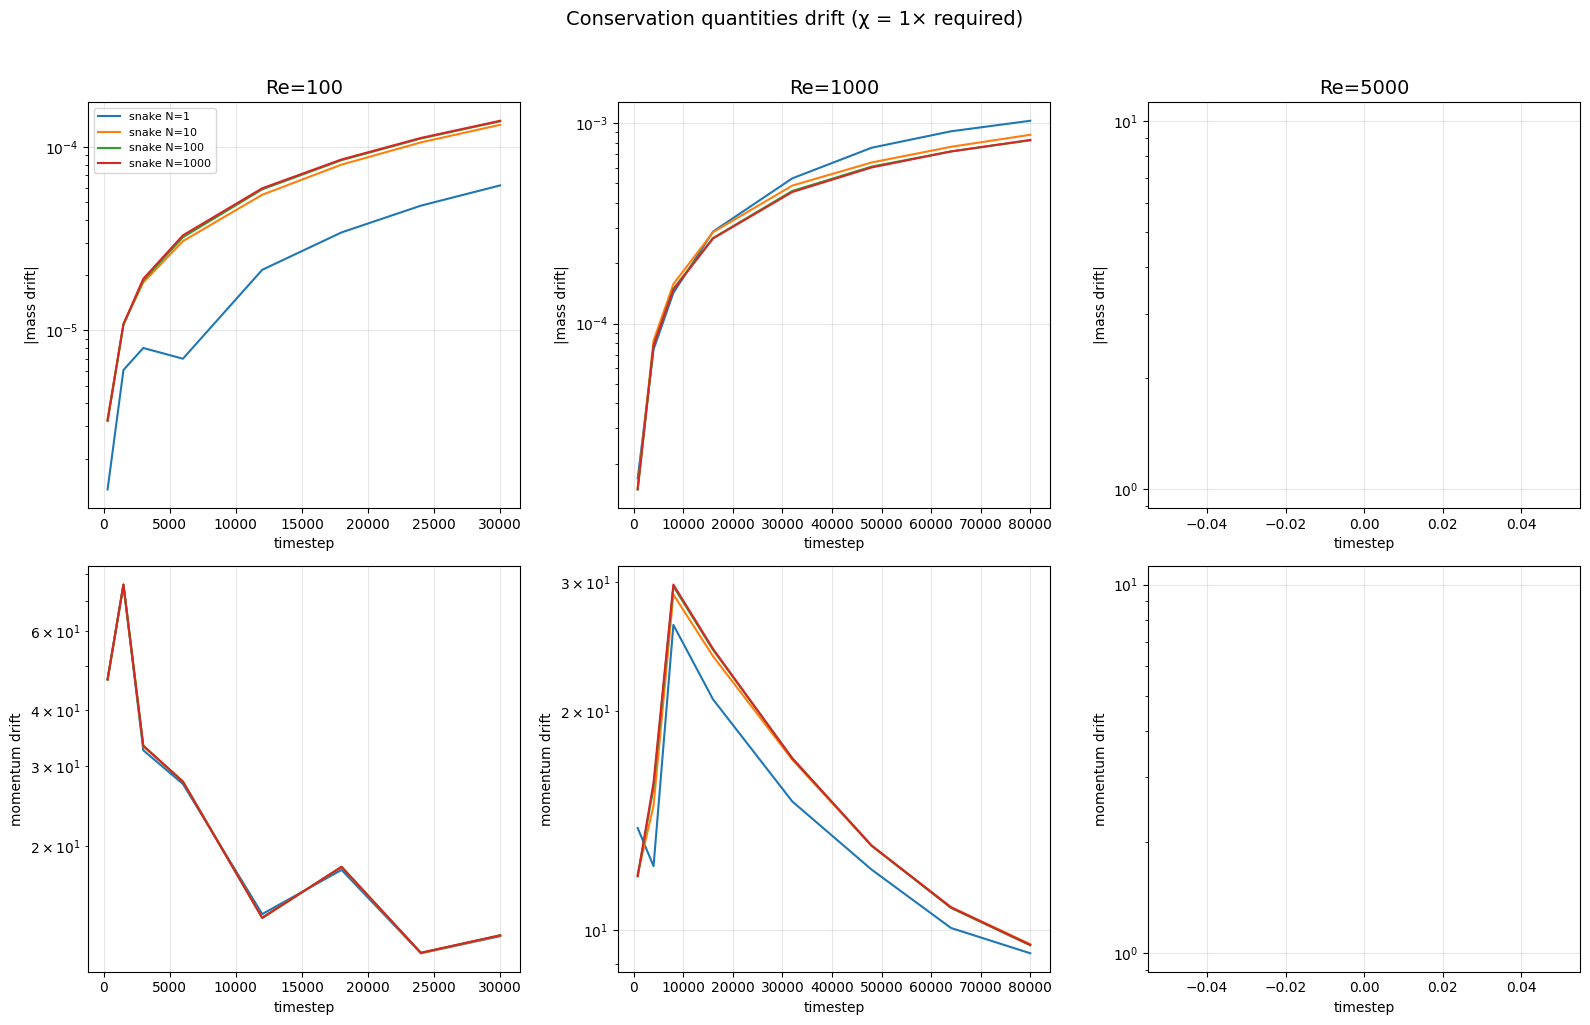

In [40]:
# Mass and momentum drift summary
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for col, Re in enumerate(RE_VALUES):
    results = all_results[Re]
    
    # Mass drift (top row)
    ax = axes[0, col]
    for mapping in MAPPINGS:
        for N in N_VALUES:
            key = (mapping, 1.0, N)  # Only show 1x chi
            if key not in results:
                continue
            
            errors = results[key]['errors']
            ts = [e['t'] for e in errors]
            mass_drifts = [abs(e['mass_drift']) for e in errors]
            
            style = '-' if mapping == 'snake' else '--'
            ax.semilogy(ts, mass_drifts, style, color=colors_N[N], 
                       label=f"{mapping} N={N}", linewidth=1.5)
    
    ax.set_xlabel('timestep')
    ax.set_ylabel('|mass drift|')
    ax.set_title(f'Re={Re}', fontsize=14)
    ax.grid(True, alpha=0.3)
    if col == 0:
        ax.legend(fontsize=8)
    
    # Momentum drift (bottom row)
    ax = axes[1, col]
    for mapping in MAPPINGS:
        for N in N_VALUES:
            key = (mapping, 1.0, N)
            if key not in results:
                continue
            
            errors = results[key]['errors']
            ts = [e['t'] for e in errors]
            mom_drifts = [e['momentum_drift'] for e in errors]
            
            style = '-' if mapping == 'snake' else '--'
            ax.semilogy(ts, mom_drifts, style, color=colors_N[N], linewidth=1.5)
    
    ax.set_xlabel('timestep')
    ax.set_ylabel('momentum drift')
    ax.grid(True, alpha=0.3)

plt.suptitle('Conservation quantities drift (χ = 1× required)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Summary Tables

In [41]:
# Final error summary table
print("="*80)
print("FINAL VELOCITY ERROR SUMMARY")
print("="*80)

for Re in RE_VALUES:
    print(f"\nRe = {Re}")
    print(f"{'mapping':>8} {'χ_mult':>8} {'N=1':>12} {'N=10':>12} {'N=100':>12} {'N=1000':>12}")
    print("-" * 70)
    
    results = all_results[Re]
    for mapping in MAPPINGS:
        for chi_mult in CHI_MULTIPLIERS:
            row = f"{mapping:>8} {chi_mult:>8.1f}"
            for N in N_VALUES:
                key = (mapping, chi_mult, N)
                if key in results:
                    result = results[key]
                    # Check for special status (DIVERGED, SKIPPED)
                    if 'status' in result and result['status'] in ['DIVERGED', 'SKIPPED']:
                        row += f" {'DIVERGED':>12}" if result['status'] == 'DIVERGED' else f" {'SKIPPED':>12}"
                    else:
                        err = result['errors'][-1]['u_err']
                        if np.isinf(err):
                            row += f" {'DIVERGED':>12}"
                        else:
                            row += f" {err:>12.2e}"
                else:
                    row += f" {'N/A':>12}"
            print(row)

FINAL VELOCITY ERROR SUMMARY

Re = 100
 mapping   χ_mult          N=1         N=10        N=100       N=1000
----------------------------------------------------------------------
   snake      1.0     1.85e-02     9.55e-03     3.74e-03     2.81e-03
   snake      1.5     3.09e-03     8.95e-04     3.02e-04     2.41e-04
   snake      2.0     3.24e-03     8.49e-04     2.77e-04     2.20e-04

Re = 1000
 mapping   χ_mult          N=1         N=10        N=100       N=1000
----------------------------------------------------------------------
   snake      1.0     9.65e-02     4.61e-02     2.06e-02     9.02e-03
   snake      1.5     1.58e-02     9.08e-03     3.58e-03     1.68e-03
   snake      2.0     5.36e-03     1.83e-03     6.68e-04     4.29e-04

Re = 5000
 mapping   χ_mult          N=1         N=10        N=100       N=1000
----------------------------------------------------------------------
   snake      1.0     1.91e-01     1.98e-01     DIVERGED      SKIPPED
   snake      1.5     1.77

In [42]:
# Stability summary: which configurations stayed below 1% error?
print("="*80)
print("STABILITY SUMMARY: Final u_err < 1%?")
print("="*80)

for Re in RE_VALUES:
    print(f"\nRe = {Re}")
    print(f"{'mapping':>8} {'χ_mult':>8} {'N=1':>8} {'N=10':>8} {'N=100':>8} {'N=1000':>8}")
    print("-" * 55)
    
    results = all_results[Re]
    for mapping in MAPPINGS:
        for chi_mult in CHI_MULTIPLIERS:
            row = f"{mapping:>8} {chi_mult:>8.1f}"
            for N in N_VALUES:
                key = (mapping, chi_mult, N)
                if key in results:
                    result = results[key]
                    # Check for special status
                    if 'status' in result and result['status'] in ['DIVERGED', 'SKIPPED']:
                        status = "DIV" if result['status'] == 'DIVERGED' else "SKIP"
                    else:
                        err = result['errors'][-1]['u_err']
                        if np.isinf(err) or np.isnan(err):
                            status = "DIV"
                        else:
                            status = "OK" if err < 0.01 else "FAIL"
                    row += f" {status:>8}"
                else:
                    row += f" {'N/A':>8}"
            print(row)

STABILITY SUMMARY: Final u_err < 1%?

Re = 100
 mapping   χ_mult      N=1     N=10    N=100   N=1000
-------------------------------------------------------
   snake      1.0     FAIL       OK       OK       OK
   snake      1.5       OK       OK       OK       OK
   snake      2.0       OK       OK       OK       OK

Re = 1000
 mapping   χ_mult      N=1     N=10    N=100   N=1000
-------------------------------------------------------
   snake      1.0     FAIL     FAIL     FAIL       OK
   snake      1.5     FAIL       OK       OK       OK
   snake      2.0       OK       OK       OK       OK

Re = 5000
 mapping   χ_mult      N=1     N=10    N=100   N=1000
-------------------------------------------------------
   snake      1.0     FAIL     FAIL      DIV     SKIP
   snake      1.5     FAIL     FAIL     FAIL     FAIL
   snake      2.0     FAIL     FAIL     FAIL     FAIL


## 9. Grid Refinement Study: Re=100, 512 vs 256

Compare compression behavior on a 512×512 grid vs the 256×256 results above.

**Key question:** Does doubling the grid size require proportionally higher χ, or does the required bond dimension scale logarithmically?

In [52]:
# Step 1: Run baseline on 512 grid (no compression)
print("=== Re=100, 512×512 Baseline ===")
baseline_512, params_512 = run_cavity_with_compression(
    n=512, Re=100, compress_every=None, nt=30000, verbose=True
)
print(f"\nBaseline done. τ={params_512['tau']:.4f}")

=== Re=100, 512×512 Baseline ===
Re=100, τ=2.0360, compression: none
  t=   300/30000 (  1.0%), u_max=0.1017, compressions=0
  t=  1500/30000 (  5.0%), u_max=0.1003, compressions=0
  t=  3000/30000 ( 10.0%), u_max=0.1004, compressions=0
  t=  6000/30000 ( 20.0%), u_max=0.1004, compressions=0
  t= 12000/30000 ( 40.0%), u_max=0.1001, compressions=0
  t= 18000/30000 ( 60.0%), u_max=0.1002, compressions=0
  t= 24000/30000 ( 80.0%), u_max=0.1001, compressions=0
  t= 30000/30000 (100.0%), u_max=0.1002, compressions=0

Baseline done. τ=2.0360


In [53]:
# Step 2: Find required χ for 512 grid (single compress/decompress at final state)
# Reconstruct final f by re-running (we need f, not just u)
from tn.compression import compress_populations, decompress_populations

print("Finding required χ for 512×512, Re=100, snake mapping...")
print(f"{'χ':>6} {'u_err':>12} {'< 1%?':>8}")
print("-" * 30)

# Run a fresh simulation to get final f
n_512 = 512
Re_test = 100
u_lid = 0.1
nu = u_lid * n_512 / Re_test
tau = 3 * nu + 0.5

walls, lid = create_cavity_walls(n_512)
u_wall = np.array([u_lid, 0.0])

rho = np.ones((n_512, n_512))
u = np.zeros((2, n_512, n_512))
f_512 = compute_equilibrium(D2Q9, rho, u)

for t in range(1, 30001):
    f_512 = collide_bgk(D2Q9, f_512, tau)
    f_512 = stream(D2Q9, f_512)
    f_512 = apply_bounce_back(D2Q9, f_512, walls)
    f_512 = apply_bounce_back_moving_top(D2Q9, f_512, u_wall)

rho_ref, u_ref_512 = compute_moments(D2Q9, f_512)

chi_required_512 = None
for chi_test in [8, 10, 12, 14, 16, 18, 20, 24, 28, 32]:
    mps_list, meta = compress_populations(f_512, max_bond=chi_test, mapping='snake')
    f_recon = decompress_populations(mps_list, meta)
    _, u_recon = compute_moments(D2Q9, f_recon)
    err = compute_velocity_error(u_recon, u_ref_512)
    ok = "YES" if err < 0.01 else "no"
    print(f"{chi_test:>6} {err:>12.2e} {ok:>8}")
    if err < 0.01 and chi_required_512 is None:
        chi_required_512 = chi_test

print(f"\nRequired χ for 512×512: {chi_required_512}")
print(f"(Compare: 256×256 required χ=12)")

Finding required χ for 512×512, Re=100, snake mapping...
     χ        u_err    < 1%?
------------------------------
     8     1.56e-02       no
    10     6.84e-03      YES
    12     3.00e-03      YES
    14     1.33e-03      YES
    16     6.13e-04      YES
    18     3.54e-04      YES
    20     2.80e-04      YES
    24     2.51e-04      YES
    28     2.50e-04      YES
    32     2.50e-04      YES

Required χ for 512×512: 10
(Compare: 256×256 required χ=12)


In [54]:
# Step 3: Run compression experiments on 512 grid
# Use the same multipliers and N values as 256 grid
results_512 = {}

# Use chi_required_512 from previous cell (fallback to 12 if not found)
chi_base_512 = chi_required_512 if chi_required_512 is not None else 12
print(f"Using χ_base = {chi_base_512} for 512×512 grid\n")

for chi_mult in CHI_MULTIPLIERS:
    chi = int(chi_base_512 * chi_mult)
    
    for N in N_VALUES:
        print(f"\n512×512, Re=100, snake, χ={chi} ({chi_mult}x), N={N}")
        
        snapshots, params = run_cavity_with_compression(
            n=512, Re=100,
            compress_every=N, max_bond=chi, mapping='snake',
            nt=30000, verbose=True
        )
        
        # Compare to 512 baseline
        errors = compare_to_reference(snapshots, baseline_512)
        
        results_512[(chi_mult, N)] = {
            'snapshots': snapshots,
            'params': params,
            'errors': errors,
            'chi': chi,
        }
        
        final_err = errors[-1]['u_err']
        print(f"  Final u_err: {final_err:.2e}")

Using χ_base = 10 for 512×512 grid


512×512, Re=100, snake, χ=10 (1.0x), N=1
Re=100, τ=2.0360, compression: every 1 steps, χ=10
  t=   300/30000 (  1.0%), u_max=0.1020, compressions=300
  t=  1500/30000 (  5.0%), u_max=0.1003, compressions=1500
  t=  3000/30000 ( 10.0%), u_max=0.1006, compressions=3000
  t=  6000/30000 ( 20.0%), u_max=0.1005, compressions=6000
  t= 12000/30000 ( 40.0%), u_max=0.1003, compressions=12000
  t= 18000/30000 ( 60.0%), u_max=0.1003, compressions=18000
  t= 24000/30000 ( 80.0%), u_max=0.1003, compressions=24000
  t= 30000/30000 (100.0%), u_max=0.1003, compressions=30000
  Final u_err: 6.14e-02

512×512, Re=100, snake, χ=10 (1.0x), N=10
Re=100, τ=2.0360, compression: every 10 steps, χ=10
  t=   300/30000 (  1.0%), u_max=0.1020, compressions=30
  t=  1500/30000 (  5.0%), u_max=0.1004, compressions=150
  t=  3000/30000 ( 10.0%), u_max=0.1009, compressions=300
  t=  6000/30000 ( 20.0%), u_max=0.1010, compressions=600
  t= 12000/30000 ( 40.0%), u_max=0.1006, compr

In [55]:
# Step 4: Compare 256 vs 512 results
print("="*90)
print("GRID REFINEMENT COMPARISON: Re=100, 256 vs 512")
print("="*90)

print(f"\n{'grid':>6} {'χ_base':>8} {'χ_mult':>8} {'χ':>6} {'N=1':>12} {'N=10':>12} {'N=100':>12} {'N=1000':>12}")
print("-" * 85)

for chi_mult in CHI_MULTIPLIERS:
    # 256 results
    chi_256 = int(12 * chi_mult)
    row = f"{'256':>6} {'12':>8} {chi_mult:>8.1f} {chi_256:>6}"
    for N in N_VALUES:
        key = ('snake', chi_mult, N)
        if key in results_100:
            err = results_100[key]['errors'][-1]['u_err']
            row += f" {err:>12.2e}"
        else:
            row += f" {'N/A':>12}"
    print(row)
    
    # 512 results
    chi_512_val = int(chi_base_512 * chi_mult)
    row = f"{'512':>6} {chi_base_512:>8} {chi_mult:>8.1f} {chi_512_val:>6}"
    for N in N_VALUES:
        key = (chi_mult, N)
        if key in results_512:
            err = results_512[key]['errors'][-1]['u_err']
            row += f" {err:>12.2e}"
        else:
            row += f" {'N/A':>12}"
    print(row)
    print()

print("\nScaling analysis:")
print(f"  256×256: L=8 sites (2^8), χ_required = 12")
print(f"  512×512: L=9 sites (2^9), χ_required = {chi_base_512}")
if chi_base_512 is not None:
    ratio = chi_base_512 / 12
    print(f"  χ ratio (512/256) = {ratio:.2f}")
    if ratio < 1.5:
        print(f"  -> Bond dimension scales sub-linearly with grid size (good!)")
    else:
        print(f"  -> Bond dimension scales more than linearly (concerning)")

GRID REFINEMENT COMPARISON: Re=100, 256 vs 512

  grid   χ_base   χ_mult      χ          N=1         N=10        N=100       N=1000
-------------------------------------------------------------------------------------
   256       12      1.0     12          N/A          N/A          N/A          N/A
   512       10      1.0     10     6.14e-02     2.92e-02     1.18e-02     7.10e-03

   256       12      1.5     18          N/A          N/A          N/A          N/A
   512       10      1.5     15     1.16e-02     3.35e-03     1.36e-03     9.17e-04

   256       12      2.0     24          N/A          N/A          N/A          N/A
   512       10      2.0     20     8.94e-03     1.36e-03     4.26e-04     2.85e-04


Scaling analysis:
  256×256: L=8 sites (2^8), χ_required = 12
  512×512: L=9 sites (2^9), χ_required = 10
  χ ratio (512/256) = 0.83
  -> Bond dimension scales sub-linearly with grid size (good!)


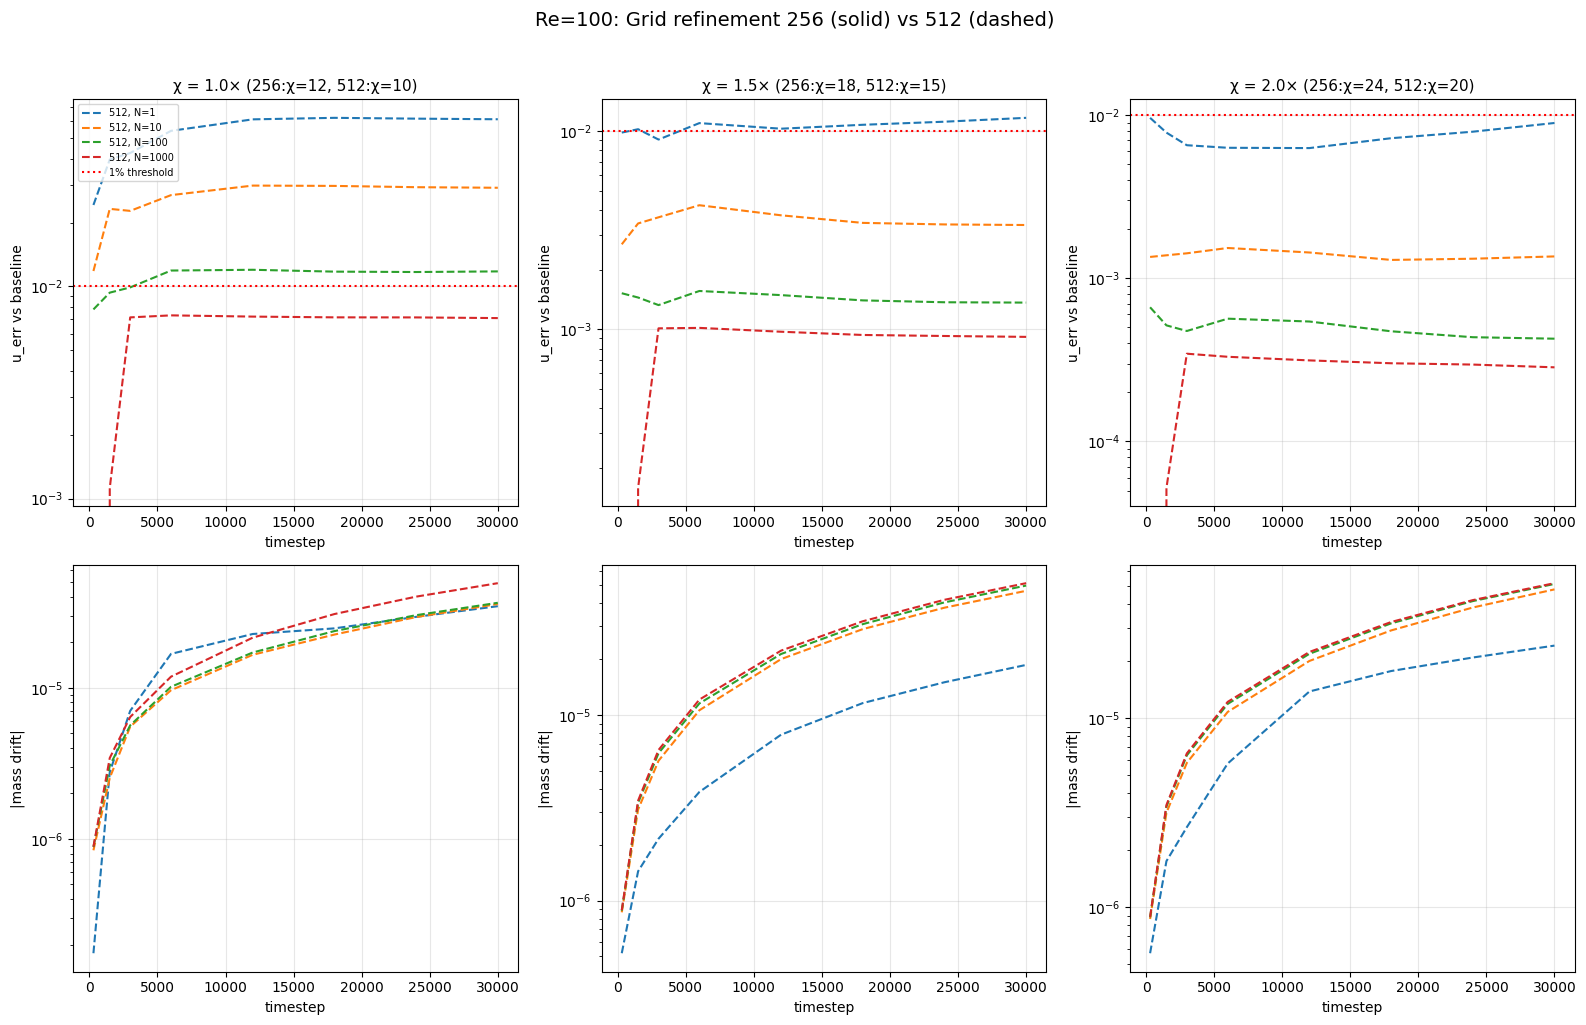

In [56]:
# Step 5: Plot 256 vs 512 comparison
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for col, chi_mult in enumerate(CHI_MULTIPLIERS):
    # Top row: velocity error over time
    ax = axes[0, col]
    
    chi_256 = int(12 * chi_mult)
    chi_512_val = int(chi_base_512 * chi_mult)
    
    for N in N_VALUES:
        # 256 results (solid)
        key_256 = ('snake', chi_mult, N)
        if key_256 in results_100:
            errors = results_100[key_256]['errors']
            ts = [e['t'] for e in errors]
            u_errs = [e['u_err'] for e in errors]
            ax.semilogy(ts, u_errs, '-', color=colors_N[N], linewidth=1.5,
                       label=f'256, N={N}')
        
        # 512 results (dashed)
        key_512 = (chi_mult, N)
        if key_512 in results_512:
            errors = results_512[key_512]['errors']
            ts = [e['t'] for e in errors]
            u_errs = [e['u_err'] for e in errors]
            ax.semilogy(ts, u_errs, '--', color=colors_N[N], linewidth=1.5,
                       label=f'512, N={N}')
    
    ax.set_title(f'χ = {chi_mult}× (256:χ={chi_256}, 512:χ={chi_512_val})', fontsize=11)
    ax.set_xlabel('timestep')
    ax.set_ylabel('u_err vs baseline')
    ax.axhline(0.01, color='red', linestyle=':', label='1% threshold')
    ax.grid(True, alpha=0.3)
    if col == 0:
        ax.legend(fontsize=7, loc='upper left')
    
    # Bottom row: mass drift
    ax = axes[1, col]
    for N in N_VALUES:
        key_256 = ('snake', chi_mult, N)
        if key_256 in results_100:
            errors = results_100[key_256]['errors']
            ts = [e['t'] for e in errors]
            mass_drifts = [abs(e['mass_drift']) for e in errors]
            ax.semilogy(ts, mass_drifts, '-', color=colors_N[N], linewidth=1.5)
        
        key_512 = (chi_mult, N)
        if key_512 in results_512:
            errors = results_512[key_512]['errors']
            ts = [e['t'] for e in errors]
            mass_drifts = [abs(e['mass_drift']) for e in errors]
            ax.semilogy(ts, mass_drifts, '--', color=colors_N[N], linewidth=1.5)
    
    ax.set_xlabel('timestep')
    ax.set_ylabel('|mass drift|')
    ax.grid(True, alpha=0.3)

plt.suptitle('Re=100: Grid refinement 256 (solid) vs 512 (dashed)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---

## 10. Re vs χ_min Scaling Experiment (Restructured)

**Goal:** Find the minimum bond dimension χ required for <1% error as a function of Reynolds number.

**Two-Phase Approach:**
1. **Phase 1:** Run baselines (no compression) for all Re values to find convergence times
2. **Phase 2:** Run compression experiments using known convergence times

**Settings:**
- Convergence tolerance: 1e-5 (velocity change)
- Maximum timesteps: 200,000
- Grids: 256×256 and 512×512
- Re values: 100, 200, 400, 800, 1000, 1500, 2000, 2500, 3000

In [106]:
# Experiment parameters
RE_VALUES = [50, 100, 200, 400, 800, 1000, 1500, 2000, 2500, 3000]
MAX_NT = 200000  # Maximum timesteps before declaring "did not converge"
CONVERGENCE_TOL = 1e-5  # RELATIVE velocity change per step (literature standard)
CHI_SEARCH_VALUES = [4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 28, 32, 48, 64, 96, 128]
ERROR_THRESHOLD = 0.01  # 1% error for χ_min search

print("Re vs χ_min Scaling Experiment - Parameters")
print("=" * 60)
print(f"Re values: {RE_VALUES}")
print(f"Max timesteps: {MAX_NT:,}")
print(f"Convergence tolerance: {CONVERGENCE_TOL}")
print(f"χ search range: {CHI_SEARCH_VALUES[0]} to {CHI_SEARCH_VALUES[-1]}")
print(f"Error threshold: {ERROR_THRESHOLD*100}%")
print()
print("Expected τ values (must be > 0.5 for stability):")
print(f"{'Grid':>6} {'Re':>6} {'ν_latt':>10} {'τ':>8} {'stable':>8}")
print("-" * 45)
for n in [256, 512]:
    for Re in [100, 1000, 3000]:
        nu = 0.1 * n / Re
        tau = 3 * nu + 0.5
        stable = "yes" if tau > 0.52 else "marginal" if tau > 0.5 else "NO"
        print(f"{n:>6} {Re:>6} {nu:>10.4f} {tau:>8.4f} {stable:>8}")

Re vs χ_min Scaling Experiment - Parameters
Re values: [50, 100, 200, 400, 800, 1000, 1500, 2000, 2500, 3000]
Max timesteps: 200,000
Convergence tolerance: 1e-05
χ search range: 4 to 128
Error threshold: 1.0%

Expected τ values (must be > 0.5 for stability):
  Grid     Re     ν_latt        τ   stable
---------------------------------------------
   256    100     0.2560   1.2680      yes
   256   1000     0.0256   0.5768      yes
   256   3000     0.0085   0.5256      yes
   512    100     0.5120   2.0360      yes
   512   1000     0.0512   0.6536      yes
   512   3000     0.0171   0.5512      yes


In [108]:
def find_chi_min_binary(n, Re, baseline_u, nt, baseline_nt, chi_values, error_threshold=0.01, verbose=True):
    """
    Binary search for minimum χ that achieves < error_threshold with N=1 compression.
    
    Args:
        n: Grid size
        Re: Reynolds number
        baseline_u: Reference velocity field (from uncompressed run)
        nt: Number of timesteps to run (can include margin)
        baseline_nt: Exact timestep when baseline was captured (for comparison)
        chi_values: List of χ values to search
        error_threshold: Maximum acceptable error (default 1%)
        verbose: Print progress
    
    Returns:
        chi_min: Minimum χ found (or None if not found)
        results: Dict of all tested χ values and their errors
    """
    results = {}
    low, high = 0, len(chi_values) - 1
    chi_min = None
    
    while low <= high:
        mid = (low + high) // 2
        chi = chi_values[mid]
        
        if chi in results:
            error = results[chi]['error']
        else:
            if verbose:
                print(f"  Testing χ={chi}...", end=" ", flush=True)
            
            # Run with compression every step (N=1) - worst case
            # IMPORTANT: Capture snapshot at same timestep as baseline (nt, not nt*1.1)
            snapshots, params = run_cavity_with_compression(
                n=n, Re=Re, nt=nt,
                compress_every=1, max_bond=chi, mapping='snake',
                snapshot_times=[baseline_nt],  # Capture at exact baseline time
                convergence_tol=None,  # Don't use convergence for compressed runs
                verbose=False
            )
            
            # Check for divergence
            if len(snapshots) == 0 or snapshots[-1]['u'] is None:
                error = float('inf')
                if verbose:
                    print("DIVERGED")
            else:
                if np.any(np.isnan(snapshots[-1]['u'])):
                    error = float('inf')
                    if verbose:
                        print("DIVERGED (NaN)")
                else:
                    error = compute_velocity_error(snapshots[-1]['u'], baseline_u)
                    if verbose:
                        status = "OK" if error < error_threshold else "FAIL"
                        print(f"error={error:.2e} [{status}]")
            
            results[chi] = {'error': error, 'nt': nt}
        
        if error < error_threshold:
            chi_min = chi
            high = mid - 1  # Try smaller
        else:
            low = mid + 1   # Need larger
    
    return chi_min, results

### 10.1 Phase 1: Baseline Convergence Study

Run all baselines (no compression) to find convergence times for each (n, Re) combination.

In [101]:
# Phase 1: Run baselines for all Re values on both grids
baseline_convergence = {256: {}, 512: {}}

print("=" * 70)
print("PHASE 1: BASELINE CONVERGENCE STUDY")
print("=" * 70)
print(f"Running baselines to find convergence times (tol={CONVERGENCE_TOL})")
print(f"Maximum timesteps: {MAX_NT:,}")
print()

for n in [256, 512]:
    print(f"\n{'='*70}")
    print(f"Grid: {n}×{n}")
    print("=" * 70)
    
    for Re in RE_VALUES:
        print(f"\n--- Re={Re} ---")
        
        # Run baseline (no compression) with convergence check
        snapshots, params = run_cavity_with_compression(
            n=n, Re=Re, nt=MAX_NT, 
            compress_every=None,  # No compression
            convergence_tol=CONVERGENCE_TOL,
            # convergence_check_every=1 (default, per-step)
            verbose=True
        )
        
        # Store results
        baseline_convergence[n][Re] = {
            'converged': params['converged'],
            'nt_required': params['convergence_time'],
            'tau': params['tau'],
            'final_u': snapshots[-1]['u'].copy() if snapshots else None
        }
        
        # Summary
        status = "CONVERGED" if params['converged'] else "MAX_NT reached"
        print(f"  => {status} at t={params['convergence_time']:,} (τ={params['tau']:.4f})")

print("\n" + "=" * 70)
print("PHASE 1 COMPLETE")
print("=" * 70)

PHASE 1: BASELINE CONVERGENCE STUDY
Running baselines to find convergence times (tol=1e-05)
Maximum timesteps: 200,000


Grid: 256×256

--- Re=50 ---
Re=50, τ=2.0360, compression: none, convergence: tol=1e-05
  t=  2000/200000 (  1.0%), u_max=0.1002, Δu_rel=1.40e-04, compressions=0
  Converged at t=9569 (Δu_rel=9.88e-06 < 1e-05)
  => CONVERGED at t=9,569 (τ=2.0360)

--- Re=100 ---
Re=100, τ=1.2680, compression: none, convergence: tol=1e-05
  t=  2000/200000 (  1.0%), u_max=0.1002, Δu_rel=1.68e-04, compressions=0
  t= 10000/200000 (  5.0%), u_max=0.1002, Δu_rel=1.56e-05, compressions=0
  Converged at t=14410 (Δu_rel=9.95e-06 < 1e-05)
  => CONVERGED at t=14,410 (τ=1.2680)

--- Re=200 ---
Re=200, τ=0.8840, compression: none, convergence: tol=1e-05
  t=  2000/200000 (  1.0%), u_max=0.1002, Δu_rel=1.96e-04, compressions=0
  t= 10000/200000 (  5.0%), u_max=0.1001, Δu_rel=4.40e-05, compressions=0
  t= 20000/200000 ( 10.0%), u_max=0.1001, Δu_rel=1.99e-05, compressions=0
  Converged at t=21130 

In [102]:
# Phase 1 Summary Table
print("=" * 80)
print("PHASE 1 SUMMARY: Baseline Convergence Times")
print("=" * 80)
print()
print(f"{'Grid':>6} {'Re':>6} {'τ':>8} {'nt_converged':>14} {'Status':>12}")
print("-" * 55)

for n in [256, 512]:
    for Re in RE_VALUES:
        result = baseline_convergence[n].get(Re, {})
        tau = result.get('tau', 0)
        nt_req = result.get('nt_required', 0)
        converged = result.get('converged', False)
        status = "converged" if converged else "MAX_NT"
        print(f"{n:>6} {Re:>6} {tau:>8.4f} {nt_req:>14,} {status:>12}")
    print()

print("Baseline results saved. Ready for Phase 2 compression experiments.")

PHASE 1 SUMMARY: Baseline Convergence Times

  Grid     Re        τ   nt_converged       Status
-------------------------------------------------------
   256     50   2.0360          9,569    converged
   256    100   1.2680         14,410    converged
   256    200   0.8840         21,130    converged
   256    400   0.6920         28,205    converged
   256    800   0.5960         32,523    converged
   256   1000   0.5768         34,659    converged
   256   1500   0.5512         40,860    converged
   256   2000   0.5384         43,901    converged
   256   2500   0.5307         49,179    converged
   256   3000   0.5256         49,670    converged

   512     50   3.5720         15,554    converged
   512    100   2.0360         19,073    converged
   512    200   1.2680         24,370    converged
   512    400   0.8840         33,234    converged
   512    800   0.6920         48,158    converged
   512   1000   0.6536         55,258    converged
   512   1500   0.6024         

### 10.2 Phase 2a: Compression Experiments — 256 Grid

Using the convergence times from Phase 1, run compression experiments with N=1 (compress every step) and binary search for χ_min.

In [110]:
# Phase 2a: Compression experiments for 256 grid
scaling_results_256 = {}

print("=" * 70)
print("PHASE 2a: COMPRESSION EXPERIMENTS — 256×256 Grid")
print("=" * 70)

for Re in RE_VALUES:
    print(f"\n{'='*60}")
    print(f"Re = {Re}")
    print("=" * 60)
    
    # Get baseline info from Phase 1
    baseline_info = baseline_convergence[256].get(Re)
    if baseline_info is None or baseline_info['final_u'] is None:
        print(f"  Skipping: No baseline available")
        scaling_results_256[Re] = {'status': 'no_baseline'}
        continue
    
    baseline_u = baseline_info['final_u']
    nt_converged = baseline_info['nt_required']
    
    nt = nt_converged
    
    print(f"  Baseline converged at t={nt_converged:,}, using nt={nt:,}")
    print(f"  Binary search for χ_min (N=1 compression)...")
    
    # Binary search for χ_min
    chi_min, search_results = find_chi_min_binary(
        n=256, Re=Re, baseline_u=baseline_u, nt=nt, baseline_nt=nt_converged,
        chi_values=CHI_SEARCH_VALUES, error_threshold=ERROR_THRESHOLD,
        verbose=True
    )
    
    scaling_results_256[Re] = {
        'chi_min': chi_min,
        'tau': baseline_info['tau'],
        'nt_used': nt,
        'search_results': search_results,
        'status': 'ok' if chi_min is not None else 'no_chi_found'
    }
    
    if chi_min is not None:
        final_error = search_results[chi_min]['error']
        print(f"\n  => χ_min = {chi_min} (error = {final_error:.2e})")
    else:
        print(f"\n  => No χ found that achieves <{ERROR_THRESHOLD*100}% error!")

print("\n" + "=" * 70)
print("256 Grid compression experiments complete!")
print("=" * 70)

PHASE 2a: COMPRESSION EXPERIMENTS — 256×256 Grid

Re = 50
  Baseline converged at t=9,569, using nt=9,569
  Binary search for χ_min (N=1 compression)...
  Testing χ=20... error=2.91e-03 [OK]
  Testing χ=10... error=3.60e-02 [FAIL]
  Testing χ=14... error=6.07e-03 [OK]
  Testing χ=12... error=1.13e-02 [FAIL]

  => χ_min = 14 (error = 6.07e-03)

Re = 100
  Baseline converged at t=14,410, using nt=14,410
  Binary search for χ_min (N=1 compression)...
  Testing χ=20... error=2.93e-03 [OK]
  Testing χ=10... error=5.22e-02 [FAIL]
  Testing χ=14... error=6.32e-03 [OK]
  Testing χ=12... error=1.73e-02 [FAIL]

  => χ_min = 14 (error = 6.32e-03)

Re = 200
  Baseline converged at t=21,130, using nt=21,130
  Binary search for χ_min (N=1 compression)...
  Testing χ=20... error=4.45e-03 [OK]
  Testing χ=10... error=9.87e-02 [FAIL]
  Testing χ=14... error=1.28e-02 [FAIL]
  Testing χ=16... error=5.46e-03 [OK]

  => χ_min = 16 (error = 5.46e-03)

Re = 400
  Baseline converged at t=28,205, using nt=28,2

/Users/mymac/Desktop/master_thesis_code/tn-lbm-venv/lib/python3.12/site-packages/quimb/tensor/decomp.py:363: UserWarning: Got: Internal algorithm failed to converge., falling back to scipy gesvd driver.
  warnings.warn(f"Got: {e}, falling back to scipy gesvd driver.")


error=9.23e-02 [FAIL]
  Testing χ=32... error=7.52e-03 [OK]
  Testing χ=24... error=2.01e-02 [FAIL]
  Testing χ=28... error=1.08e-02 [FAIL]

  => χ_min = 32 (error = 7.52e-03)

Re = 2500
  Baseline converged at t=49,179, using nt=49,179
  Binary search for χ_min (N=1 compression)...
  Testing χ=20... error=7.43e-02 [FAIL]
  Testing χ=32... error=1.55e-02 [FAIL]
  Testing χ=64... error=1.08e-02 [FAIL]
  Testing χ=96... error=1.08e-02 [FAIL]
  Testing χ=128... error=1.08e-02 [FAIL]

  => No χ found that achieves <1.0% error!

Re = 3000
  Baseline converged at t=49,670, using nt=49,670
  Binary search for χ_min (N=1 compression)...
  Testing χ=20... error=2.04e-01 [FAIL]
  Testing χ=32... error=4.03e-02 [FAIL]
  Testing χ=64... error=2.95e-02 [FAIL]
  Testing χ=96... error=2.95e-02 [FAIL]
  Testing χ=128... error=2.95e-02 [FAIL]

  => No χ found that achieves <1.0% error!

256 Grid compression experiments complete!


In [111]:
# 256 Grid Results Summary
print("=" * 70)
print("RESULTS SUMMARY: 256×256 Grid — χ_min vs Re")
print("=" * 70)
print()
print(f"{'Re':>6} {'χ_min':>8} {'τ':>8} {'nt_used':>10} {'error':>12} {'status':>12}")
print("-" * 65)

re_values_256 = []
chi_min_values_256 = []

for Re in RE_VALUES:
    result = scaling_results_256.get(Re, {})
    status = result.get('status', 'missing')
    
    if status == 'ok':
        chi_min = result['chi_min']
        tau = result['tau']
        nt_used = result['nt_used']
        error = result['search_results'][chi_min]['error']
        print(f"{Re:>6} {chi_min:>8} {tau:>8.4f} {nt_used:>10,} {error:>12.2e} {status:>12}")
        re_values_256.append(Re)
        chi_min_values_256.append(chi_min)
    elif status == 'no_baseline':
        print(f"{Re:>6} {'N/A':>8} {'N/A':>8} {'N/A':>10} {'N/A':>12} {status:>12}")
    elif status == 'no_chi_found':
        tau = result.get('tau', 0)
        nt_used = result.get('nt_used', 0)
        print(f"{Re:>6} {'>128':>8} {tau:>8.4f} {nt_used:>10,} {'N/A':>12} {status:>12}")
    else:
        print(f"{Re:>6} {'N/A':>8} {'N/A':>8} {'N/A':>10} {'N/A':>12} {status:>12}")

print("-" * 65)
print(f"\nSuccessful measurements: {len(re_values_256)}/{len(RE_VALUES)}")

RESULTS SUMMARY: 256×256 Grid — χ_min vs Re

    Re    χ_min        τ    nt_used        error       status
-----------------------------------------------------------------
    50       14   2.0360      9,569     6.07e-03           ok
   100       14   1.2680     14,410     6.32e-03           ok
   200       16   0.8840     21,130     5.46e-03           ok
   400       18   0.6920     28,205     5.37e-03           ok
   800       20   0.5960     32,523     9.73e-03           ok
  1000       22   0.5768     34,659     6.92e-03           ok
  1500       28   0.5512     40,860     7.23e-03           ok
  2000       32   0.5384     43,901     7.52e-03           ok
  2500     >128   0.5307     49,179          N/A no_chi_found
  3000     >128   0.5256     49,670          N/A no_chi_found
-----------------------------------------------------------------

Successful measurements: 8/10


In [112]:
# Power law fitting for 256 grid: χ_min = A × Re^α
from scipy.optimize import curve_fit

def power_law(x, A, alpha):
    """Power law: y = A * x^alpha"""
    return A * np.power(x, alpha)

fit_256 = None

if len(re_values_256) >= 3:
    re_array = np.array(re_values_256, dtype=float)
    chi_array = np.array(chi_min_values_256, dtype=float)
    
    try:
        popt, pcov = curve_fit(power_law, re_array, chi_array, p0=[1.0, 0.3], maxfev=5000)
        A_fit, alpha_fit = popt
        perr = np.sqrt(np.diag(pcov))
        
        # R² calculation
        residuals = chi_array - power_law(re_array, *popt)
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((chi_array - np.mean(chi_array))**2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
        
        print("Power Law Fit (256×256): χ_min = A × Re^α")
        print("=" * 50)
        print(f"  A     = {A_fit:.4f} ± {perr[0]:.4f}")
        print(f"  α     = {alpha_fit:.4f} ± {perr[1]:.4f}")
        print(f"  R²    = {r_squared:.4f}")
        print()
        print(f"  => χ_min ≈ {A_fit:.3f} × Re^{alpha_fit:.3f}")
        
        fit_256 = {'A': A_fit, 'alpha': alpha_fit, 'A_err': perr[0], 'alpha_err': perr[1], 'R2': r_squared}
    except Exception as e:
        print(f"Fitting failed: {e}")
else:
    print(f"Not enough data points for fitting (need 3+, have {len(re_values_256)})")

Power Law Fit (256×256): χ_min = A × Re^α
  A     = 4.1215 ± 1.1124
  α     = 0.2570 ± 0.0399
  R²    = 0.8904

  => χ_min ≈ 4.121 × Re^0.257


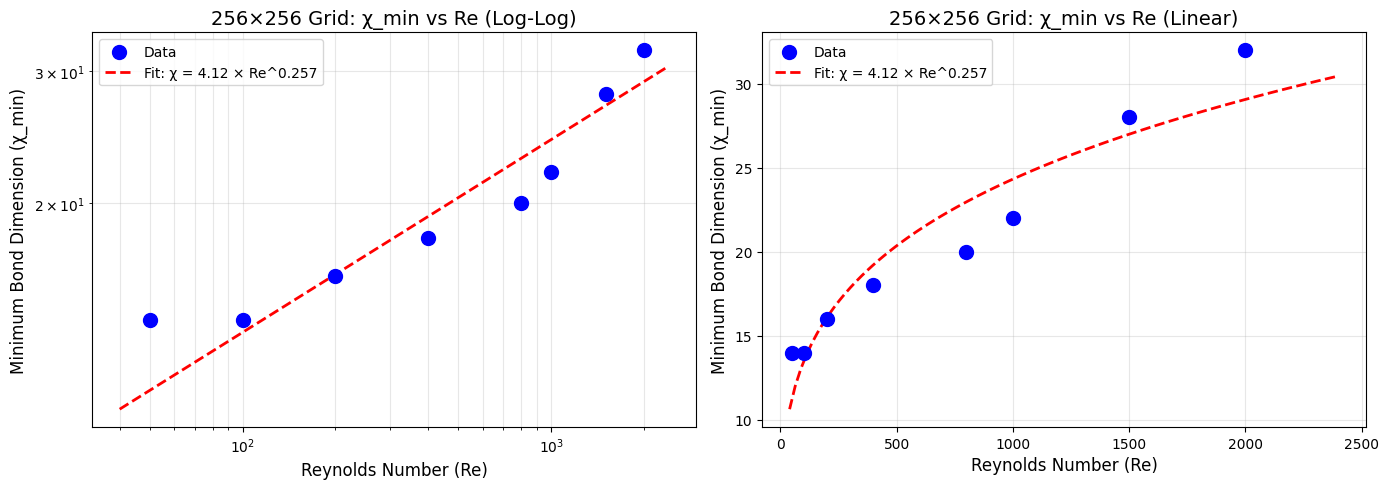


Plot saved as 're_vs_chi_256.png'


In [113]:
# Plots for 256 grid results
if len(re_values_256) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    re_plot = np.array(re_values_256)
    chi_plot = np.array(chi_min_values_256)
    
    # Plot 1: Log-log scale (for power law verification)
    ax1 = axes[0]
    ax1.scatter(re_plot, chi_plot, s=100, c='blue', marker='o', label='Data', zorder=5)
    
    if fit_256 is not None:
        re_fit = np.linspace(min(re_plot)*0.8, max(re_plot)*1.2, 100)
        chi_fit = power_law(re_fit, fit_256['A'], fit_256['alpha'])
        ax1.plot(re_fit, chi_fit, 'r--', linewidth=2, 
                 label=f"Fit: χ = {fit_256['A']:.2f} × Re^{fit_256['alpha']:.3f}")
    
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlabel('Reynolds Number (Re)', fontsize=12)
    ax1.set_ylabel('Minimum Bond Dimension (χ_min)', fontsize=12)
    ax1.set_title('256×256 Grid: χ_min vs Re (Log-Log)', fontsize=14)
    ax1.legend()
    ax1.grid(True, which='both', alpha=0.3)
    
    # Plot 2: Linear scale
    ax2 = axes[1]
    ax2.scatter(re_plot, chi_plot, s=100, c='blue', marker='o', label='Data', zorder=5)
    
    if fit_256 is not None:
        ax2.plot(re_fit, chi_fit, 'r--', linewidth=2, 
                 label=f"Fit: χ = {fit_256['A']:.2f} × Re^{fit_256['alpha']:.3f}")
    
    ax2.set_xlabel('Reynolds Number (Re)', fontsize=12)
    ax2.set_ylabel('Minimum Bond Dimension (χ_min)', fontsize=12)
    ax2.set_title('256×256 Grid: χ_min vs Re (Linear)', fontsize=14)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('re_vs_chi_256.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nPlot saved as 're_vs_chi_256.png'")
else:
    print("Not enough data points for plotting")

### 10.3 Phase 2b: Compression Experiments — 512 Grid

Using the exact convergence times from Phase 1 baselines.

In [115]:
# Phase 2b: Compression experiments for 512 grid
scaling_results_512 = {}

print("=" * 70)
print("PHASE 2b: COMPRESSION EXPERIMENTS — 512×512 Grid")
print("=" * 70)

for Re in RE_VALUES:
    print(f"\n{'='*60}")
    print(f"Re = {Re}")
    print("=" * 60)
    
    # Get baseline info from Phase 1
    baseline_info = baseline_convergence[512].get(Re)
    if baseline_info is None or baseline_info['final_u'] is None:
        print(f"  Skipping: No baseline available")
        scaling_results_512[Re] = {'status': 'no_baseline'}
        continue
    
    baseline_u = baseline_info['final_u']
    nt_converged = baseline_info['nt_required']
    
    nt = nt_converged
    
    print(f"  Baseline converged at t={nt_converged:,}, using nt={nt:,}")
    print(f"  Binary search for χ_min (N=1 compression)...")
    
    # Binary search for χ_min
    chi_min, search_results = find_chi_min_binary(
        n=512, Re=Re, baseline_u=baseline_u, nt=nt, baseline_nt=nt_converged,
        chi_values=CHI_SEARCH_VALUES, error_threshold=ERROR_THRESHOLD,
        verbose=True
    )
    
    scaling_results_512[Re] = {
        'chi_min': chi_min,
        'tau': baseline_info['tau'],
        'nt_used': nt,
        'search_results': search_results,
        'status': 'ok' if chi_min is not None else 'no_chi_found'
    }
    
    if chi_min is not None:
        final_error = search_results[chi_min]['error']
        print(f"\n  => χ_min = {chi_min} (error = {final_error:.2e})")
    else:
        print(f"\n  => No χ found that achieves <{ERROR_THRESHOLD*100}% error!")

print("\n" + "=" * 70)
print("512 Grid compression experiments complete!")
print("=" * 70)

PHASE 2b: COMPRESSION EXPERIMENTS — 512×512 Grid

Re = 50
  Baseline converged at t=15,554, using nt=15,554
  Binary search for χ_min (N=1 compression)...
  Testing χ=20... error=6.73e-03 [OK]
  Testing χ=10... error=4.60e-02 [FAIL]
  Testing χ=14... error=9.76e-03 [OK]
  Testing χ=12... error=2.08e-02 [FAIL]

  => χ_min = 14 (error = 9.76e-03)

Re = 100
  Baseline converged at t=19,073, using nt=19,073
  Binary search for χ_min (N=1 compression)...
  Testing χ=20... error=7.55e-03 [OK]
  Testing χ=10... error=6.22e-02 [FAIL]
  Testing χ=14... error=1.37e-02 [FAIL]
  Testing χ=16... error=8.58e-03 [OK]

  => χ_min = 16 (error = 8.58e-03)

Re = 200
  Baseline converged at t=24,370, using nt=24,370
  Binary search for χ_min (N=1 compression)...
  Testing χ=20... error=1.21e-02 [FAIL]
  Testing χ=32... error=1.21e-02 [FAIL]
  Testing χ=64... error=1.21e-02 [FAIL]
  Testing χ=96... error=1.21e-02 [FAIL]
  Testing χ=128... error=1.21e-02 [FAIL]

  => No χ found that achieves <1.0% error!

R

SystemError: CPUDispatcher(<function svd_truncated_numba at 0x120baa3e0>) returned a result with an exception set

In [ ]:
# 512 Grid Results Summary
print("=" * 70)
print("RESULTS SUMMARY: 512×512 Grid — χ_min vs Re")
print("=" * 70)
print()
print(f"{'Re':>6} {'χ_min':>8} {'τ':>8} {'nt_used':>10} {'error':>12} {'status':>12}")
print("-" * 65)

re_values_512 = []
chi_min_values_512 = []

for Re in RE_VALUES:
    result = scaling_results_512.get(Re, {})
    status = result.get('status', 'missing')
    
    if status == 'ok':
        chi_min = result['chi_min']
        tau = result['tau']
        nt_used = result['nt_used']
        error = result['search_results'][chi_min]['error']
        print(f"{Re:>6} {chi_min:>8} {tau:>8.4f} {nt_used:>10,} {error:>12.2e} {status:>12}")
        re_values_512.append(Re)
        chi_min_values_512.append(chi_min)
    elif status == 'no_baseline':
        print(f"{Re:>6} {'N/A':>8} {'N/A':>8} {'N/A':>10} {'N/A':>12} {status:>12}")
    elif status == 'no_chi_found':
        tau = result.get('tau', 0)
        nt_used = result.get('nt_used', 0)
        print(f"{Re:>6} {'>128':>8} {tau:>8.4f} {nt_used:>10,} {'N/A':>12} {status:>12}")
    else:
        print(f"{Re:>6} {'N/A':>8} {'N/A':>8} {'N/A':>10} {'N/A':>12} {status:>12}")

print("-" * 65)
print(f"\nSuccessful measurements: {len(re_values_512)}/{len(RE_VALUES)}")

In [ ]:
# Power law fitting for 512 grid: χ_min = A × Re^α
fit_512 = None

if len(re_values_512) >= 3:
    re_array = np.array(re_values_512, dtype=float)
    chi_array = np.array(chi_min_values_512, dtype=float)
    
    try:
        popt, pcov = curve_fit(power_law, re_array, chi_array, p0=[1.0, 0.3], maxfev=5000)
        A_fit, alpha_fit = popt
        perr = np.sqrt(np.diag(pcov))
        
        # R² calculation
        residuals = chi_array - power_law(re_array, *popt)
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((chi_array - np.mean(chi_array))**2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
        
        print("Power Law Fit (512×512): χ_min = A × Re^α")
        print("=" * 50)
        print(f"  A     = {A_fit:.4f} ± {perr[0]:.4f}")
        print(f"  α     = {alpha_fit:.4f} ± {perr[1]:.4f}")
        print(f"  R²    = {r_squared:.4f}")
        print()
        print(f"  => χ_min ≈ {A_fit:.3f} × Re^{alpha_fit:.3f}")
        
        fit_512 = {'A': A_fit, 'alpha': alpha_fit, 'A_err': perr[0], 'alpha_err': perr[1], 'R2': r_squared}
    except Exception as e:
        print(f"Fitting failed: {e}")
else:
    print(f"Not enough data points for fitting (need 3+, have {len(re_values_512)})")

In [ ]:
# Plots for 512 grid results
if len(re_values_512) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    re_plot = np.array(re_values_512)
    chi_plot = np.array(chi_min_values_512)
    
    # Plot 1: Log-log scale
    ax1 = axes[0]
    ax1.scatter(re_plot, chi_plot, s=100, c='green', marker='s', label='Data', zorder=5)
    
    if fit_512 is not None:
        re_fit = np.linspace(min(re_plot)*0.8, max(re_plot)*1.2, 100)
        chi_fit = power_law(re_fit, fit_512['A'], fit_512['alpha'])
        ax1.plot(re_fit, chi_fit, 'r--', linewidth=2, 
                 label=f"Fit: χ = {fit_512['A']:.2f} × Re^{fit_512['alpha']:.3f}")
    
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlabel('Reynolds Number (Re)', fontsize=12)
    ax1.set_ylabel('Minimum Bond Dimension (χ_min)', fontsize=12)
    ax1.set_title('512×512 Grid: χ_min vs Re (Log-Log)', fontsize=14)
    ax1.legend()
    ax1.grid(True, which='both', alpha=0.3)
    
    # Plot 2: Linear scale
    ax2 = axes[1]
    ax2.scatter(re_plot, chi_plot, s=100, c='green', marker='s', label='Data', zorder=5)
    
    if fit_512 is not None:
        ax2.plot(re_fit, chi_fit, 'r--', linewidth=2, 
                 label=f"Fit: χ = {fit_512['A']:.2f} × Re^{fit_512['alpha']:.3f}")
    
    ax2.set_xlabel('Reynolds Number (Re)', fontsize=12)
    ax2.set_ylabel('Minimum Bond Dimension (χ_min)', fontsize=12)
    ax2.set_title('512×512 Grid: χ_min vs Re (Linear)', fontsize=14)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('re_vs_chi_512.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nPlot saved as 're_vs_chi_512.png'")
else:
    print("Not enough data points for plotting")

### 10.4 Combined Analysis: 256 vs 512 Grid Comparison

Compare the scaling exponents across grid resolutions to verify:
1. **Power law exponent α** — should be similar (physics-driven, not grid-dependent)
2. **Prefactor A** — may differ (resolution-dependent)
3. **Grid size impact** — does 512 need more χ than 256 for same Re?

In [ ]:
# Combined comparison table
print("=" * 80)
print("COMBINED ANALYSIS: 256×256 vs 512×512 Grid Scaling")
print("=" * 80)

# Side-by-side χ_min comparison
print("\nχ_min values at each Re:")
print(f"{'Re':>6} {'χ_min(256)':>12} {'χ_min(512)':>12} {'ratio':>10} {'Δχ':>8}")
print("-" * 55)

for Re in RE_VALUES:
    chi_256 = scaling_results_256.get(Re, {}).get('chi_min', None)
    chi_512 = scaling_results_512.get(Re, {}).get('chi_min', None)
    
    if chi_256 is not None and chi_512 is not None:
        ratio = chi_512 / chi_256
        delta = chi_512 - chi_256
        print(f"{Re:>6} {chi_256:>12} {chi_512:>12} {ratio:>10.2f} {delta:>+8}")
    else:
        chi_256_str = str(chi_256) if chi_256 else "N/A"
        chi_512_str = str(chi_512) if chi_512 else "N/A"
        print(f"{Re:>6} {chi_256_str:>12} {chi_512_str:>12} {'N/A':>10} {'N/A':>8}")

# Power law comparison
print("\n" + "=" * 60)
print("POWER LAW FIT COMPARISON")
print("=" * 60)
print(f"{'Parameter':>15} {'256×256':>20} {'512×512':>20}")
print("-" * 60)

if fit_256 is not None:
    print(f"{'A':>15} {fit_256['A']:>15.4f} ± {fit_256['A_err']:.4f}", end="")
else:
    print(f"{'A':>15} {'N/A':>20}", end="")

if fit_512 is not None:
    print(f" {fit_512['A']:>15.4f} ± {fit_512['A_err']:.4f}")
else:
    print(f" {'N/A':>20}")

if fit_256 is not None:
    print(f"{'α':>15} {fit_256['alpha']:>15.4f} ± {fit_256['alpha_err']:.4f}", end="")
else:
    print(f"{'α':>15} {'N/A':>20}", end="")

if fit_512 is not None:
    print(f" {fit_512['alpha']:>15.4f} ± {fit_512['alpha_err']:.4f}")
else:
    print(f" {'N/A':>20}")

if fit_256 is not None:
    print(f"{'R²':>15} {fit_256['R2']:>20.4f}", end="")
else:
    print(f"{'R²':>15} {'N/A':>20}", end="")

if fit_512 is not None:
    print(f" {fit_512['R2']:>20.4f}")
else:
    print(f" {'N/A':>20}")

# Key insights
print("\n" + "=" * 60)
print("KEY INSIGHTS")
print("=" * 60)
if fit_256 is not None and fit_512 is not None:
    alpha_diff = abs(fit_256['alpha'] - fit_512['alpha'])
    print(f"- Scaling exponent difference: |α_256 - α_512| = {alpha_diff:.4f}")
    if alpha_diff < 0.1:
        print("  -> Exponents are similar! Physics-driven scaling confirmed.")
    else:
        print("  -> Exponents differ — may need more data or grid effects present.")
    
    A_ratio = fit_512['A'] / fit_256['A']
    print(f"- Prefactor ratio: A_512 / A_256 = {A_ratio:.3f}")
else:
    print("- Cannot compare fits (insufficient data for one or both grids)")

In [ ]:
# Combined plot: Both grids on same axes (Gourianov-style)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

has_256_data = len(re_values_256) >= 2
has_512_data = len(re_values_512) >= 2

# Plot 1: Log-log scale (main result)
ax1 = axes[0]

if has_256_data:
    re_256 = np.array(re_values_256)
    chi_256 = np.array(chi_min_values_256)
    ax1.scatter(re_256, chi_256, s=100, c='blue', marker='o', label='256×256', zorder=5)
    
    if fit_256 is not None:
        re_fit = np.linspace(50, 3500, 100)
        chi_fit_256 = power_law(re_fit, fit_256['A'], fit_256['alpha'])
        ax1.plot(re_fit, chi_fit_256, 'b--', linewidth=2, alpha=0.7,
                 label=f"256: χ = {fit_256['A']:.2f} × Re^{fit_256['alpha']:.3f}")

if has_512_data:
    re_512 = np.array(re_values_512)
    chi_512 = np.array(chi_min_values_512)
    ax1.scatter(re_512, chi_512, s=100, c='green', marker='s', label='512×512', zorder=5)
    
    if fit_512 is not None:
        re_fit = np.linspace(50, 3500, 100)
        chi_fit_512 = power_law(re_fit, fit_512['A'], fit_512['alpha'])
        ax1.plot(re_fit, chi_fit_512, 'g--', linewidth=2, alpha=0.7,
                 label=f"512: χ = {fit_512['A']:.2f} × Re^{fit_512['alpha']:.3f}")

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Reynolds Number (Re)', fontsize=12)
ax1.set_ylabel('Minimum Bond Dimension (χ_min)', fontsize=12)
ax1.set_title('Re vs χ_min Scaling (Log-Log)', fontsize=14)
ax1.legend(loc='upper left')
ax1.grid(True, which='both', alpha=0.3)

# Plot 2: Linear scale
ax2 = axes[1]

if has_256_data:
    ax2.scatter(re_256, chi_256, s=100, c='blue', marker='o', label='256×256', zorder=5)
    if fit_256 is not None:
        ax2.plot(re_fit, chi_fit_256, 'b--', linewidth=2, alpha=0.7)

if has_512_data:
    ax2.scatter(re_512, chi_512, s=100, c='green', marker='s', label='512×512', zorder=5)
    if fit_512 is not None:
        ax2.plot(re_fit, chi_fit_512, 'g--', linewidth=2, alpha=0.7)

ax2.set_xlabel('Reynolds Number (Re)', fontsize=12)
ax2.set_ylabel('Minimum Bond Dimension (χ_min)', fontsize=12)
ax2.set_title('Re vs χ_min Scaling (Linear)', fontsize=14)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('re_vs_chi_combined.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPlot saved as 're_vs_chi_combined.png'")

In [ ]:
# Save all results to file
import json
from datetime import datetime

def convert_for_json(obj):
    """Convert numpy types for JSON serialization."""
    if isinstance(obj, np.ndarray):
        return None  # Don't save full arrays
    if isinstance(obj, (np.int64, np.int32)):
        return int(obj)
    if isinstance(obj, (np.float64, np.float32)):
        return float(obj)
    return obj

results_summary = {
    'experiment': 'Re vs chi_min scaling (with convergence)',
    'date': datetime.now().isoformat(),
    'parameters': {
        'convergence_tol': CONVERGENCE_TOL,
        'max_nt': MAX_NT,
        'error_threshold': ERROR_THRESHOLD,
        'chi_search_range': [CHI_SEARCH_VALUES[0], CHI_SEARCH_VALUES[-1]],
        're_values': RE_VALUES,
    },
    'baseline_convergence': {
        '256': {str(Re): {
            'converged': baseline_convergence[256][Re].get('converged'),
            'nt_required': baseline_convergence[256][Re].get('nt_required'),
            'tau': baseline_convergence[256][Re].get('tau'),
        } for Re in RE_VALUES if Re in baseline_convergence[256]},
        '512': {str(Re): {
            'converged': baseline_convergence[512][Re].get('converged'),
            'nt_required': baseline_convergence[512][Re].get('nt_required'),
            'tau': baseline_convergence[512][Re].get('tau'),
        } for Re in RE_VALUES if Re in baseline_convergence[512]},
    },
    'scaling_results_256': {str(Re): {
        'chi_min': convert_for_json(scaling_results_256[Re].get('chi_min')),
        'tau': convert_for_json(scaling_results_256[Re].get('tau')),
        'nt_used': convert_for_json(scaling_results_256[Re].get('nt_used')),
        'status': scaling_results_256[Re].get('status'),
    } for Re in RE_VALUES if Re in scaling_results_256},
    'scaling_results_512': {str(Re): {
        'chi_min': convert_for_json(scaling_results_512[Re].get('chi_min')),
        'tau': convert_for_json(scaling_results_512[Re].get('tau')),
        'nt_used': convert_for_json(scaling_results_512[Re].get('nt_used')),
        'status': scaling_results_512[Re].get('status'),
    } for Re in RE_VALUES if Re in scaling_results_512},
    'fit_256': fit_256,
    'fit_512': fit_512,
}

with open('re_scaling_results.json', 'w') as f:
    json.dump(results_summary, f, indent=2)

print("All results saved to 're_scaling_results.json'")
print(f"\nExperiment completed: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# Stage 3: Memory-Equivalent Comparison

## TN-LBM vs Coarse Vanilla LBM

Compare compression-based TN-LBM against vanilla LBM on coarser grids with **equivalent memory usage**.

**Key Question:** For a given memory budget, which approach gives better accuracy?

### Memory Equivalence

For TN-LBM with bond dimension χ on an N×N grid:
- Memory = 9 populations × 2log₂(N) sites × χ² floats per site = **144 × χ²** (for N=256)

For vanilla LBM on N_coarse × N_coarse grid:
- Memory = 9 × N_coarse² floats

Setting equal: N_coarse = 4 × χ (for N_fine=256)

In [ ]:
# Stage 3: Helper Functions and Constants
from scipy.ndimage import zoom

# χ values to test
CHI_VALUES_STAGE3 = [6, 8, 10, 12, 14, 16, 18, 20, 24, 28, 32, 36, 40, 48, 56, 64]

def compute_memory(method, N, chi=None):
    """Compute memory usage in number of floats."""
    if method == 'vanilla':
        return 9 * N * N  # 9 populations × N^2
    elif method == 'tn':
        L = 2 * int(np.log2(N))  # chain length per population
        return 9 * L * chi * chi  # 9 populations × L sites × χ^2 per site

def memory_equivalent_grid(N_fine, chi):
    """Compute N_coarse for vanilla LBM with same memory as TN-LBM."""
    tn_memory = compute_memory('tn', N_fine, chi)
    return int(np.sqrt(tn_memory / 9))

# Quick check: memory-equivalent grid sizes
print("Memory-equivalent grids for N_fine=256:")
print(f"{'χ':>4} | {'TN Memory':>10} | {'N_coarse':>8}")
print("-" * 30)
for chi in [6, 10, 14, 20, 32, 64]:
    print(f"{chi:>4} | {compute_memory('tn', 256, chi):>10,} | {memory_equivalent_grid(256, chi):>8}")

Memory-equivalent grids for N_fine=256:
   χ |  TN Memory | N_coarse
------------------------------
   6 |      5,184 |       24
  10 |     14,400 |       40
  14 |     28,224 |       56
  20 |     57,600 |       80
  32 |    147,456 |      128
  64 |    589,824 |      256


In [153]:
# Check what existing data we have from Stage 2
print("Checking existing data from Stage 2...")
print("-" * 50)

# Check baseline
if 256 in baseline_convergence and 100 in baseline_convergence[256]:
    info = baseline_convergence[256][100]
    print(f"✓ Baseline (N=256, Re=100): nt={info['nt_required']}")
else:
    print("✗ No baseline for N=256, Re=100")

# Check TN-LBM results
existing_tn = {}
if 100 in scaling_results_256:
    search_results = scaling_results_256[100].get('search_results', {})
    for chi, data in search_results.items():
        if 'error' in data and not np.isnan(data['error']):
            existing_tn[chi] = data['error']

print(f"\n✓ Existing TN-LBM results: {sorted(existing_tn.keys())}")
print(f"  Need to run: {sorted([c for c in CHI_VALUES_STAGE3 if c not in existing_tn])}")

Checking existing data from Stage 2...
--------------------------------------------------
✓ Baseline (N=256, Re=100): nt=14410

✓ Existing TN-LBM results: [10, 12, 14, 20]
  Need to run: [6, 8, 16, 18, 24, 28, 32, 36, 40, 48, 56, 64]


In [ ]:
# Main experiment function

def run_memory_comparison(N_fine, Re, chi_values, verbose=True):
    """
    Compare TN-LBM vs coarse vanilla LBM at same memory budget.
    """
    results = []
    MAX_NT_COARSE = 200000  # Same as baseline MAX_NT
    CONV_TOL = 1e-5  # Same as baseline
    
    print("=" * 60)
    print(f"STAGE 3: Memory Comparison")
    print(f"N_fine={N_fine}, Re={Re}")
    print("=" * 60)
    
    # Step 1: Get baseline from Stage 2
    print(f"\n[1] Loading baseline from Stage 2...")
    baseline_info = baseline_convergence[N_fine].get(Re)
    if baseline_info is None:
        raise ValueError(f"No baseline for N={N_fine}, Re={Re}. Run Stage 2 first!")
    
    u_baseline = baseline_info['final_u']
    nt_baseline = baseline_info['nt_required']
    print(f"  nt_converged={nt_baseline}, memory={compute_memory('vanilla', N_fine):,} floats")
    
    # Get existing TN-LBM results
    existing_tn = {}
    if Re in scaling_results_256:
        for chi, data in scaling_results_256[Re].get('search_results', {}).items():
            if 'error' in data and not np.isnan(data['error']):
                existing_tn[chi] = data['error']
    
    print(f"\n[2] Processing {len(chi_values)} χ values...")
    print("-" * 60)
    
    for i, chi in enumerate(chi_values):
        memory = compute_memory('tn', N_fine, chi)
        N_coarse = memory_equivalent_grid(N_fine, chi)
        
        print(f"\n[χ={chi}] memory={memory:,}, N_coarse={N_coarse} ({i+1}/{len(chi_values)})")
        
        # --- TN-LBM ---
        if chi in existing_tn:
            error_tn = existing_tn[chi]
            print(f"  TN-LBM: reusing, error={error_tn:.4e}")
        else:
            print(f"  TN-LBM: running for nt={nt_baseline}...")
            try:
                # Returns (snapshots, params) tuple
                snapshots, params = run_cavity_with_compression(
                    n=N_fine, Re=Re, nt=nt_baseline,
                    compress_every=1, max_bond=chi,
                    mapping='snake', verbose=False
                )
                u_tn = snapshots[-1]['u']
                error_tn = compute_velocity_error(u_tn, u_baseline)
                print(f"  TN-LBM: error={error_tn:.4e}")
            except Exception as e:
                print(f"  TN-LBM: FAILED - {e}")
                error_tn = np.nan
        
        # --- Coarse LBM ---
        print(f"  Coarse LBM (N={N_coarse}): running until convergence...")
        try:
            nu = 0.1 * N_coarse / Re
            tau = 3 * nu + 0.5
            
            walls, lid = create_cavity_walls(N_coarse)
            u_wall = np.array([0.1, 0.0])
            
            rho = np.ones((N_coarse, N_coarse))
            u_prev = np.zeros((2, N_coarse, N_coarse))
            f = compute_equilibrium(D2Q9, rho, u_prev)
            
            converged = False
            nt_coarse = MAX_NT_COARSE
            
            for t in range(MAX_NT_COARSE):
                f = collide_bgk(D2Q9, f, tau)
                f = stream(D2Q9, f)
                f = apply_bounce_back(D2Q9, f, walls)
                f = apply_bounce_back_moving_top(D2Q9, f, u_wall)
                
                # Check convergence EVERY step (like baseline)
                rho_new, u_new = compute_moments(D2Q9, f)
                u_change = np.max(np.abs(u_new - u_prev)) / (np.max(np.abs(u_new)) + 1e-10)
                u_prev = u_new.copy()
                
                if u_change < CONV_TOL:
                    nt_coarse = t
                    converged = True
                    break
                
                # Progress for large grids
                if t > 0 and t % 10000 == 0:
                    print(f"    ... t={t}, u_change={u_change:.2e}")
            
            rho_final, u_coarse = compute_moments(D2Q9, f)
            
            # Interpolate to fine grid
            u_coarse_interp = np.zeros_like(u_baseline)
            scale = N_fine / N_coarse
            for dim in range(2):
                u_coarse_interp[dim] = zoom(u_coarse[dim], scale, order=3)
            
            error_coarse = compute_velocity_error(u_coarse_interp, u_baseline)
            conv_status = "" if converged else " (max iter)"
            print(f"  Coarse LBM: nt={nt_coarse}{conv_status}, error={error_coarse:.4e}")
            
        except Exception as e:
            print(f"  Coarse LBM: FAILED - {e}")
            error_coarse = np.nan
        
        winner = "TN" if error_tn < error_coarse else "Coarse"
        print(f"  => Winner: {winner}")
        
        results.append({
            'chi': chi, 'memory': memory, 'N_coarse': N_coarse,
            'error_tn': error_tn, 'error_coarse': error_coarse,
            'tn_reused': chi in existing_tn
        })
    
    return results, u_baseline

In [155]:
def plot_memory_comparison(results, N_fine, Re):
    """Plot memory vs error comparison."""
    
    memory = [r['memory'] for r in results]
    error_tn = [r['error_tn'] for r in results]
    error_coarse = [r['error_coarse'] for r in results]
    chi_vals = [r['chi'] for r in results]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Log-log scale comparison
    ax1 = axes[0]
    ax1.loglog(memory, error_tn, 'bo-', label='TN-LBM', markersize=8, linewidth=2)
    ax1.loglog(memory, error_coarse, 'rs-', label='Coarse LBM', markersize=8, linewidth=2)
    
    for m, e_tn, chi in zip(memory, error_tn, chi_vals):
        if not np.isnan(e_tn):
            ax1.annotate(f'χ={chi}', (m, e_tn), textcoords="offset points", 
                        xytext=(5, 5), fontsize=8, color='blue')
    
    ax1.set_xlabel('Memory (floats)', fontsize=12)
    ax1.set_ylabel('Relative L2 Error', fontsize=12)
    ax1.set_title(f'Memory vs Accuracy (N={N_fine}, Re={Re})', fontsize=14)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Which method wins?
    ax2 = axes[1]
    error_ratio = [e_c / e_t if (e_t > 0 and not np.isnan(e_t) and not np.isnan(e_c)) else np.nan 
                   for e_c, e_t in zip(error_coarse, error_tn)]
    
    valid_idx = [i for i, r in enumerate(error_ratio) if not np.isnan(r)]
    valid_mem = [memory[i] for i in valid_idx]
    valid_ratio = [error_ratio[i] for i in valid_idx]
    
    ax2.semilogx(valid_mem, valid_ratio, 'go-', markersize=8, linewidth=2)
    ax2.axhline(y=1.0, color='k', linestyle='--', label='Equal accuracy')
    ax2.set_xlabel('Memory (floats)', fontsize=12)
    ax2.set_ylabel('Error Ratio (Coarse / TN)', fontsize=12)
    ax2.set_title('Which Method Wins? (>1 = TN wins)', fontsize=14)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'memory_comparison_N{N_fine}_Re{Re}.png', dpi=150)
    plt.show()
    
    # Summary table
    print("\n" + "=" * 75)
    print("RESULTS SUMMARY")
    print("=" * 75)
    print(f"{'χ':>4} | {'Memory':>10} | {'N_coarse':>8} | {'TN Err':>10} | {'Coarse Err':>10} | {'Winner':>10}")
    print("-" * 75)
    for r in results:
        winner = "TN-LBM" if r['error_tn'] < r['error_coarse'] else "Coarse"
        reused = "(reused)" if r.get('tn_reused', False) else ""
        print(f"{r['chi']:>4} | {r['memory']:>10,} | {r['N_coarse']:>8} | "
              f"{r['error_tn']:>10.4e} | {r['error_coarse']:>10.4e} | {winner:>10} {reused}")

### 3.1 Run Memory Comparison: Re=100, N=256

Full comparison across all χ values.

In [ ]:
# Stage 3 Experiment: Memory Comparison
# Reuses baseline and existing TN-LBM results from Stage 2
# CHI_VALUES_STAGE3 defined in helper cell above

# Run the experiment (reuses existing data where available)
results_256_re100, u_baseline_256 = run_memory_comparison(
    N_fine=256, 
    Re=100, 
    chi_values=CHI_VALUES_STAGE3
)

# Plot results
plot_memory_comparison(results_256_re100, N_fine=256, Re=100)

In [157]:
# Save Stage 3 results
stage3_results = {
    'N_fine': 256,
    'Re': 100,
    'chi_values': CHI_VALUES_STAGE3,
    'results': results_256_re100,
    'timestamp': datetime.now().isoformat()
}

with open('tn/stage3_memory_comparison_results.json', 'w') as f:
    json.dump(stage3_results, f, indent=2, default=lambda x: float(x) if isinstance(x, np.floating) else x)

print("Results saved to tn/stage3_memory_comparison_results.json")

NameError: name 'datetime' is not defined